# Phase 1 - Validation Suite: State Nonfarm Payrolls (CES)

**Scope:** validate the state total-nonfarm-payroll dataset (`{ABBR}NA`, monthly seasonally adjusted, level in thousands, BLS Current Employment Statistics via FRED/ALFRED) before any modeling. NSA (`{ABBR}NAN`) is pulled for the seasonality contrast; national PAYEMS for reconciliation.

**Downstream uses and what they stress:**

| Use case | Failure modes probed here |
|---|---|
| Forecasting | trend/stationarity, residual seasonality in SA data, outliers, breaks (V5, V7) |
| Lead-lag | timestamp & alignment conventions, sign orientation vs unemployment (V3, V8) |
| Backtesting | point-in-time integrity, **benchmark revisions**, publication lag, look-ahead guards (V3, V4, V9) |

**How NFP differs from continued claims (the sister dataset).** These two series sit at opposite ends of the revision spectrum, and the suite is tuned accordingly:

| | State continued claims | **State nonfarm payrolls** |
|---|---|---|
| Frequency | weekly (Sat week-ending) | **monthly** (pay period incl. the 12th) |
| Seasonal adjustment | NSA only | **SA** (seasonality should be *absent* - a QC flip in V7) |
| Revised after first print? | ~0% (essentially never) | **~99%** - monthly re-estimates + **annual benchmark** revisions to QCEW |
| Level behaviour | cyclical, mean-reverting | **trending** (I(1) with drift) |
| Publication lag | ~10 days | **~50 days** (joint State Employment & Unemployment report, ~3 wks after the national jobs report) |
| Sum-of-states vs national | PR/VI gap (~1.4%) | **near-exact** (ratio ~1.0002) |

The headline consequence: for claims, current data ≈ first release, so point-in-time was a *nicety*. For NFP, **PIT is mandatory** - current values are contaminated by future benchmark revisions the modeller could not have known (V4, V9). Each check states its question and pass criterion up front; the last cells render the report and go/no-go gates.

In [1]:
import os, time, json, hashlib
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FRED_API_KEY = os.getenv("FRED_API_KEY", "12d77a40907e43a92e9a295801db18d2")
FRED_URL     = "https://api.stlouisfed.org/fred/series/observations"

DATA_FILES = {
    "vintage": "nfp_vintage_first_release.csv",
    "current": "nfp_current_history.csv",
    "pit":     "nfp_pit_features.csv",
}

# ── Check registry ────────────────────────────────────────────────────────────
checks = []

def add_check(module, check_id, name, result, metric="", threshold="", note=""):
    assert result in ("PASS", "WARN", "FAIL")
    checks.append(dict(module=module, id=check_id, check=name, result=result,
                       metric=str(metric), threshold=str(threshold), note=note))
    print(f"[{result:4s}] {check_id:6s} {name}  |  {metric}  (criterion: {threshold})")
    if note:
        print(f"       note: {note}")


def fred_get(params, retries=5):
    params = {**params, "api_key": FRED_API_KEY, "file_type": "json"}
    for attempt in range(retries):
        data = requests.get(FRED_URL, params=params, timeout=180).json()
        if "error_message" in data:
            if "Too Many Requests" in data["error_message"]:
                time.sleep(2 ** (attempt + 1)); continue
            raise ValueError(data["error_message"])
        return data
    raise RuntimeError(f"Rate limit persists: {params.get('series_id')}")


def fred_obs(params, retries=5):
    return [o for o in fred_get(params, retries).get("observations", []) if o["value"] != "."]

print("Setup ok.")

Setup ok.


## Maintained hypotheses - CES publication mechanics

**H1 - Publication schedule.** State total nonfarm payrolls are published in the BLS *State Employment and Unemployment* report, released monthly roughly **three weeks after** the national Employment Situation (jobs) report - about **7 weeks (~50 days) after the reference month**, typically on a Friday.
→ tested by **V3.2** (release weekday), **V3.3** (publication lag ≈ 50 days).

**H2 - Reference period.** The payroll figure counts employees on payrolls for the pay period that **includes the 12th** of the reference month; FRED stamps the observation on the **1st of that month**.
→ tested by **V2.1** (all observation dates are month-starts).

**H3 - Revision structure.** CES estimates are revised in the two months after first release (sample completion) and then **benchmarked annually** to the near-universe QCEW count - the benchmark, published each winter with the January data, restates roughly the prior 21 months. This makes current data a poor proxy for what was known in real time.
→ quantified by **V4** (first-vs-current revision, benchmark-month clustering) and **V9** (feature contamination).

**Vocabulary.** *First release* = the initial (preliminary) estimate for a month, stamped by its `first_release_date`. *Current* = the latest value after all monthly and benchmark revisions. *Benchmark revision* = the annual QCEW re-anchoring. *Two clocks* = observation time (the month measured, V2) vs information time (when it became known, V3).

## V0 - Build the dataset from the FRED/ALFRED API (self-contained)

Fetches everything it validates - no other notebook needs to run first. **V0a** auto-loads on-disk CSVs when vintage + current exist (pit too if present); otherwise it fetches the SA ALFRED first-release table (`output_type=4`), SA current history and NSA current history (~155 calls, ~3-4 min). Set `FORCE_REFRESH = True` in V0a to ignore cache. **V0b** assembles the monthly point-in-time panel if pit is missing, persists three CSVs and pulls national benchmarks.

In [2]:
# ── V0a. Fetch state NFP data from the FRED/ALFRED API ────────────────────────
FORCE_REFRESH = False   # True -> ignore on-disk CSVs and re-fetch from the API

V0A_CACHE_KEYS = ("vintage", "current")   # V0a only needs these; pit is built in V0b


def _cache_file_info(path):
    """Return size/mtime for an on-disk CSV, or None if missing."""
    if not os.path.exists(path):
        return None
    st = os.stat(path)
    return {"path": path, "size_mb": st.st_size / 1e6,
            "mtime": pd.Timestamp(st.st_mtime, unit="s")}


_cache_status = {k: _cache_file_info(DATA_FILES[k]) for k in DATA_FILES}
_v0a_cache_ok = all(_cache_status[k] for k in V0A_CACHE_KEYS)
_full_cache_ok = all(_cache_status.values())

print("V0a — cache probe:")
for key, info in _cache_status.items():
    path = DATA_FILES[key]
    if info is None:
        print(f"  {key:8s}  missing  ({path})")
    else:
        print(f"  {key:8s}  ok  {info['size_mb']:6.1f} MB  mtime {info['mtime'].date()}  ({path})")

if _full_cache_ok:
    print("  → will load vintage, current, and pit from cache.")
elif _v0a_cache_ok:
    print("  → will load vintage and current from cache; pit will be rebuilt in V0b.")
else:
    print("  → no cache — will fetch from FRED/ALFRED (~155 calls, ~3-4 min).")

STATES = [
    ("Alabama","AL","01"),("Alaska","AK","02"),("Arizona","AZ","04"),("Arkansas","AR","05"),
    ("California","CA","06"),("Colorado","CO","08"),("Connecticut","CT","09"),("Delaware","DE","10"),
    ("District of Columbia","DC","11"),("Florida","FL","12"),("Georgia","GA","13"),("Hawaii","HI","15"),
    ("Idaho","ID","16"),("Illinois","IL","17"),("Indiana","IN","18"),("Iowa","IA","19"),
    ("Kansas","KS","20"),("Kentucky","KY","21"),("Louisiana","LA","22"),("Maine","ME","23"),
    ("Maryland","MD","24"),("Massachusetts","MA","25"),("Michigan","MI","26"),("Minnesota","MN","27"),
    ("Mississippi","MS","28"),("Missouri","MO","29"),("Montana","MT","30"),("Nebraska","NE","31"),
    ("Nevada","NV","32"),("New Hampshire","NH","33"),("New Jersey","NJ","34"),("New Mexico","NM","35"),
    ("New York","NY","36"),("North Carolina","NC","37"),("North Dakota","ND","38"),("Ohio","OH","39"),
    ("Oklahoma","OK","40"),("Oregon","OR","41"),("Pennsylvania","PA","42"),("Rhode Island","RI","44"),
    ("South Carolina","SC","45"),("South Dakota","SD","46"),("Tennessee","TN","47"),("Texas","TX","48"),
    ("Utah","UT","49"),("Vermont","VT","50"),("Virginia","VA","51"),("Washington","WA","53"),
    ("West Virginia","WV","54"),("Wisconsin","WI","55"),("Wyoming","WY","56"),
]
# Series: {ABBR}NA = SA total nonfarm (validated series); {ABBR}NAN = NSA (seasonality contrast)


def fetch_vintage(series_id):
    return fred_obs({"series_id": series_id, "realtime_start": "1776-07-04",
                     "realtime_end": "9999-12-31", "output_type": 4, "limit": 100000})

def fetch_current(series_id):
    return fred_obs({"series_id": series_id, "observation_start": "1990-01-01", "limit": 100000})


if _v0a_cache_ok and not FORCE_REFRESH:
    df_v = pd.read_csv(DATA_FILES["vintage"], parse_dates=["obs_date", "first_release_date"])
    df_c = pd.read_csv(DATA_FILES["current"], parse_dates=["obs_date"])
    if _full_cache_ok:
        pit = pd.read_csv(DATA_FILES["pit"], parse_dates=["as_of_date", "nfp_latest_obs"])
        print("Loaded cached CSVs (vintage, current, pit).")
    else:
        pit = None
        print("Loaded cached CSVs (vintage, current). pit will be rebuilt in V0b.")
else:
    if _v0a_cache_ok and FORCE_REFRESH:
        print("FORCE_REFRESH=True — ignoring on-disk cache, fetching from API.")
    vintage_rows, current_rows, failed = [], [], []
    for i, (name, abbr, fips) in enumerate(STATES):
        try:
            for o in fetch_vintage(f"{abbr}NA"):
                vintage_rows.append({"state": name, "abbr": abbr, "fips": fips,
                    "obs_date": pd.to_datetime(o["date"]),
                    "first_release_date": pd.to_datetime(o["realtime_start"]),
                    "superseded_date": o["realtime_end"], "value_first_release": float(o["value"])})
            time.sleep(0.3)
            for o in fetch_current(f"{abbr}NA"):
                current_rows.append({"state": name, "abbr": abbr, "adjustment": "sa",
                    "obs_date": pd.to_datetime(o["date"]), "value_current": float(o["value"])})
            time.sleep(0.3)
            for o in fetch_current(f"{abbr}NAN"):
                current_rows.append({"state": name, "abbr": abbr, "adjustment": "nsa",
                    "obs_date": pd.to_datetime(o["date"]), "value_current": float(o["value"])})
            print(f"[{i+1:2d}/51] {abbr}NA / {abbr}NAN ok")
        except Exception as e:
            print(f"[{i+1:2d}/51] {abbr} FAILED - {e}"); failed.append(abbr)
        time.sleep(0.3)
    if failed:
        raise RuntimeError(f"Fetch failed for {failed} - re-run this cell (rate limits are transient).")
    df_v = pd.DataFrame(vintage_rows)
    df_v["is_current"]   = df_v["superseded_date"] == "9999-12-31"
    df_v["pub_lag_days"] = (df_v["first_release_date"] - df_v["obs_date"]).dt.days
    df_v = df_v.drop(columns="superseded_date")
    df_c = pd.DataFrame(current_rows)
    pit = None

print(f"vintage rows: {len(df_v):,}   current rows: {len(df_c):,}")

[ 1/51] ALNA / ALNAN ok
[ 2/51] AKNA / AKNAN ok
[ 3/51] AZNA / AZNAN ok
[ 4/51] ARNA / ARNAN ok
[ 5/51] CANA / CANAN ok
[ 6/51] CONA / CONAN ok
[ 7/51] CTNA / CTNAN ok
[ 8/51] DENA / DENAN ok
[ 9/51] DCNA / DCNAN ok
[10/51] FLNA / FLNAN ok
[11/51] GANA / GANAN ok
[12/51] HINA / HINAN ok
[13/51] IDNA / IDNAN ok
[14/51] ILNA / ILNAN ok
[15/51] INNA / INNAN ok
[16/51] IANA / IANAN ok
[17/51] KSNA / KSNAN ok
[18/51] KYNA / KYNAN ok
[19/51] LANA / LANAN ok
[20/51] MENA / MENAN ok
[21/51] MDNA / MDNAN ok
[22/51] MANA / MANAN ok
[23/51] MINA / MINAN ok
[24/51] MNNA / MNNAN ok
[25/51] MSNA / MSNAN ok
[26/51] MONA / MONAN ok
[27/51] MTNA / MTNAN ok
[28/51] NENA / NENAN ok
[29/51] NVNA / NVNAN ok
[30/51] NHNA / NHNAN ok
[31/51] NJNA / NJNAN ok
[32/51] NMNA / NMNAN ok
[33/51] NYNA / NYNAN ok
[34/51] NCNA / NCNAN ok
[35/51] NDNA / NDNAN ok
[36/51] OHNA / OHNAN ok
[37/51] OKNA / OKNAN ok
[38/51] ORNA / ORNAN ok
[39/51] PANA / PANAN ok
[40/51] RINA / RINAN ok
[41/51] SCNA / SCNAN ok
[42/51] SDNA / S

In [3]:
# ── V0b. Assemble the monthly point-in-time panel, persist, fetch benchmarks ──
N_LAGS = 13   # months of history per as-of date (enables MoM, 3m, 6m, YoY)

if pit is None:
    AS_OF_GRID = pd.date_range(df_v["first_release_date"].min().to_period("M").to_timestamp(),
                               df_v["first_release_date"].max().to_period("M").to_timestamp(), freq="MS")

    def build_pit(vint, n_lags, grid):
        """Last n_lags monthly first-release readings available at each as-of month.
        Releases are append-only, so the cummax of release dates is the availability
        frontier; searchsorted gives the released-prefix length at each as-of date."""
        out = {}
        for state, g in vint.groupby("state", sort=False):
            g = g.sort_values("obs_date")
            rel_eff = g["first_release_date"].cummax().values
            vals = g["value_first_release"].values
            obsd = g["obs_date"].values
            n_avail = np.searchsorted(rel_eff, grid.values, side="right")
            for j, as_of in enumerate(grid):
                k = n_avail[j]
                if k < n_lags:
                    continue
                row = {f"nfp_t{m}": vals[k - 1 - m] for m in range(n_lags)}
                row["nfp_latest_obs"] = pd.Timestamp(obsd[k - 1])
                row["nfp_lag_months"] = (as_of.to_period("M") - pd.Timestamp(obsd[k - 1]).to_period("M")).n
                out[(as_of, state)] = row
        return out

    pit = pd.DataFrame([{"as_of_date": k[0], "state": k[1], **row}
                        for k, row in build_pit(df_v, N_LAGS, AS_OF_GRID).items()])
    pit["nfp_mom1_pct"] = (pit["nfp_t0"] / pit["nfp_t1"]  - 1) * 100
    pit["nfp_mom3_pct"] = (pit["nfp_t0"] / pit["nfp_t3"]  - 1) * 100
    pit["nfp_yoy_pct"]  = (pit["nfp_t0"] / pit["nfp_t12"] - 1) * 100
    df_v.to_csv(DATA_FILES["vintage"], index=False)
    df_c.to_csv(DATA_FILES["current"], index=False)
    pit.to_csv(DATA_FILES["pit"], index=False)
    print("Dataset written to CSVs.")

sa_c  = df_c[df_c["adjustment"] == "sa"].copy()    # SA current history (validated series)
nsa_c = df_c[df_c["adjustment"] == "nsa"].copy()   # NSA current history (seasonality contrast)
print(f"pit rows: {len(pit):,}   SA current: {len(sa_c):,}   NSA current: {len(nsa_c):,}")

# National benchmarks: PAYEMS (SA) current + first-release table + vintage dates
nat_cur = pd.DataFrame(fred_obs({"series_id": "PAYEMS", "observation_start": "1990-01-01", "limit": 100000}))
nat_cur["obs_date"] = pd.to_datetime(nat_cur["date"]); nat_cur["value"] = nat_cur["value"].astype(float)
nat_v = pd.DataFrame(fred_obs({"series_id": "PAYEMS", "realtime_start": "1776-07-04",
                               "realtime_end": "9999-12-31", "output_type": 4, "limit": 100000}))
nat_v["obs_date"] = pd.to_datetime(nat_v["date"]); nat_v["first_release_date"] = pd.to_datetime(nat_v["realtime_start"])
nat_v["value"] = nat_v["value"].astype(float)
nat_v["pub_lag_days"] = (nat_v["first_release_date"] - nat_v["obs_date"]).dt.days
nat_vdates = pd.to_datetime(pd.Series(requests.get(
    "https://api.stlouisfed.org/fred/series/vintagedates",
    params={"series_id": "PAYEMS", "api_key": FRED_API_KEY, "file_type": "json", "limit": 10000},
    timeout=60).json()["vintage_dates"]))
print(f"national PAYEMS: {len(nat_cur)} current obs, {len(nat_v)} first releases, {len(nat_vdates)} vintage dates")

Dataset written to CSVs.
pit rows: 11,133   SA current: 22,287   NSA current: 22,287
national PAYEMS: 438 current obs, 854 first releases, 857 vintage dates


## V1 — Structural integrity

| Check | Question it answers |
|---|---|
| V1.1 | Do we actually have all 51 states in every table? |
| V1.2 | Is (state, month) a unique key — no double-loaded rows? |
| V1.3 | Are the key fields complete (no nulls)? |
| V1.4 | Is every payroll level finite and strictly positive? |
| V1.4b | Are the levels a plausible employment magnitude (digit-error / scale guard)? |
| V1.5 | Did any state's fetch silently truncate? |

The validated series is seasonally-adjusted total nonfarm payrolls (`{ABBR}NA`), a level in thousands of persons. NSA (`{ABBR}NAN`) is auxiliary. Datasets: **vintage** = first-release (`df_v`), **current** = revised (`sa_c`), **pit** = point-in-time panel.

## V1.0 — Print datasets

In [4]:
df_v.head()

,state,abbr,fips,obs_date,first_release_date,value_first_release,is_current,pub_lag_days
0,Alabama,AL,01,2007-06-01,2007-07-20,2011.5,False,49
1,Alabama,AL,01,2007-07-01,2007-08-17,2011.6,False,47
2,Alabama,AL,01,2007-08-01,2007-09-25,2017.0,False,55
3,Alabama,AL,01,2007-09-01,2007-10-19,2019.0,False,48
4,Alabama,AL,01,2007-10-01,2007-11-20,2015.8,False,50


In [37]:
df_v[['obs_date', 'first_release_date', 'value_first_release', 'pub_lag_days']].describe()

,obs_date,first_release_date,value_first_release,pub_lag_days
count,11796,11796,11796.000000,11796.000000
mean,2016-09-21 15:49:30.091556608,2016-11-13 03:11:10.193285888,2814.584164,52.473381
min,2005-06-01 00:00:00,2005-07-22 00:00:00,248.700000,45.000000
25%,2011-12-01 00:00:00,2012-01-24 00:00:00,758.200000,48.000000
50%,2016-10-01 00:00:00,2016-11-18 00:00:00,1881.150000,50.000000
75%,2021-08-01 00:00:00,2021-09-17 00:00:00,3450.500000,53.000000
max,2026-05-01 00:00:00,2026-06-23 00:00:00,18180.700000,101.000000
std,NaN,NaN,3048.950440,8.990903


In [38]:
sa_c.head()

,state,abbr,adjustment,obs_date,value_current
0,Alabama,AL,sa,1990-01-01,1635.5
1,Alabama,AL,sa,1990-02-01,1633.5
2,Alabama,AL,sa,1990-03-01,1632.0
3,Alabama,AL,sa,1990-04-01,1643.7
4,Alabama,AL,sa,1990-05-01,1648.9


In [39]:
sa_c[['obs_date', 'value_current']].describe()

,obs_date,value_current
count,22287,22287.000000
mean,2008-03-01 13:14:08.512585728,2630.646839
min,1990-01-01 00:00:00,195.700000
25%,1999-02-01 00:00:00,694.900000
50%,2008-03-01 00:00:00,1744.200000
75%,2017-04-01 00:00:00,3233.900000
max,2026-05-01 00:00:00,18166.100000
std,NaN,2848.405017


In [40]:
pit.head()

,as_of_date,state,nfp_t0,nfp_t1,nfp_t2,nfp_t3,nfp_t4,nfp_t5,nfp_t6,nfp_t7,nfp_t8,nfp_t9,nfp_t10,nfp_t11,nfp_t12,nfp_latest_obs,nfp_lag_months,nfp_mom1_pct,nfp_mom3_pct,nfp_yoy_pct
0,2008-08-01,Alabama,2012.9,2011.5,2013.3,2014.8,2016.2,2016.8,2021.7,2018.7,2015.8,2019.0,2017.0,2011.6,2011.5,2008-06-01,2,0.069600,-0.094302,0.069600
1,2008-09-01,Alabama,2015.3,2012.9,2011.5,2013.3,2014.8,2016.2,2016.8,2021.7,2018.7,2015.8,2019.0,2017.0,2011.6,2008-07-01,2,0.119231,0.099339,0.183933
2,2008-10-01,Alabama,2014.7,2015.3,2012.9,2011.5,2013.3,2014.8,2016.2,2016.8,2021.7,2018.7,2015.8,2019.0,2017.0,2008-08-01,2,-0.029772,0.159085,-0.114031
3,2008-11-01,Alabama,2011.1,2014.7,2015.3,2012.9,2011.5,2013.3,2014.8,2016.2,2016.8,2021.7,2018.7,2015.8,2019.0,2008-09-01,2,-0.178687,-0.089423,-0.391283
4,2008-12-01,Alabama,2008.9,2011.1,2014.7,2015.3,2012.9,2011.5,2013.3,2014.8,2016.2,2016.8,2021.7,2018.7,2015.8,2008-10-01,2,-0.109393,-0.317571,-0.342296


In [41]:
pit[['as_of_date', 'nfp_latest_obs', 'nfp_t0']].describe()

,as_of_date,nfp_latest_obs,nfp_t0
count,11133,11133,11133.000000
mean,2017-05-07 16:22:07.081649408,2017-03-03 23:04:07.372676096,2819.661071
min,2006-08-01 00:00:00,2006-06-01 00:00:00,248.700000
25%,2012-11-01 00:00:00,2012-09-01 00:00:00,759.400000
50%,2017-05-01 00:00:00,2017-03-01 00:00:00,1882.300000
75%,2021-12-01 00:00:00,2021-10-01 00:00:00,3470.600000
max,2026-06-01 00:00:00,2026-04-01 00:00:00,18180.700000
std,NaN,NaN,3057.389042


## V1.1 — Count and plot number of states per dataset

V1.1 — unique states per table (criterion: 51 everywhere):
  vintage   51  [OK]
  current   51  [OK]
  pit       51  [OK]


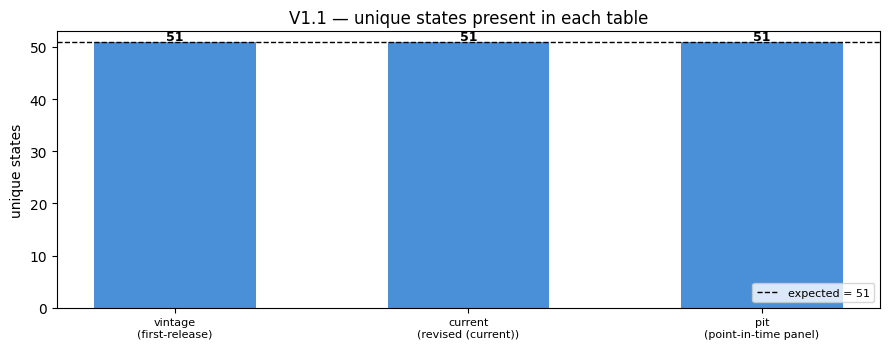

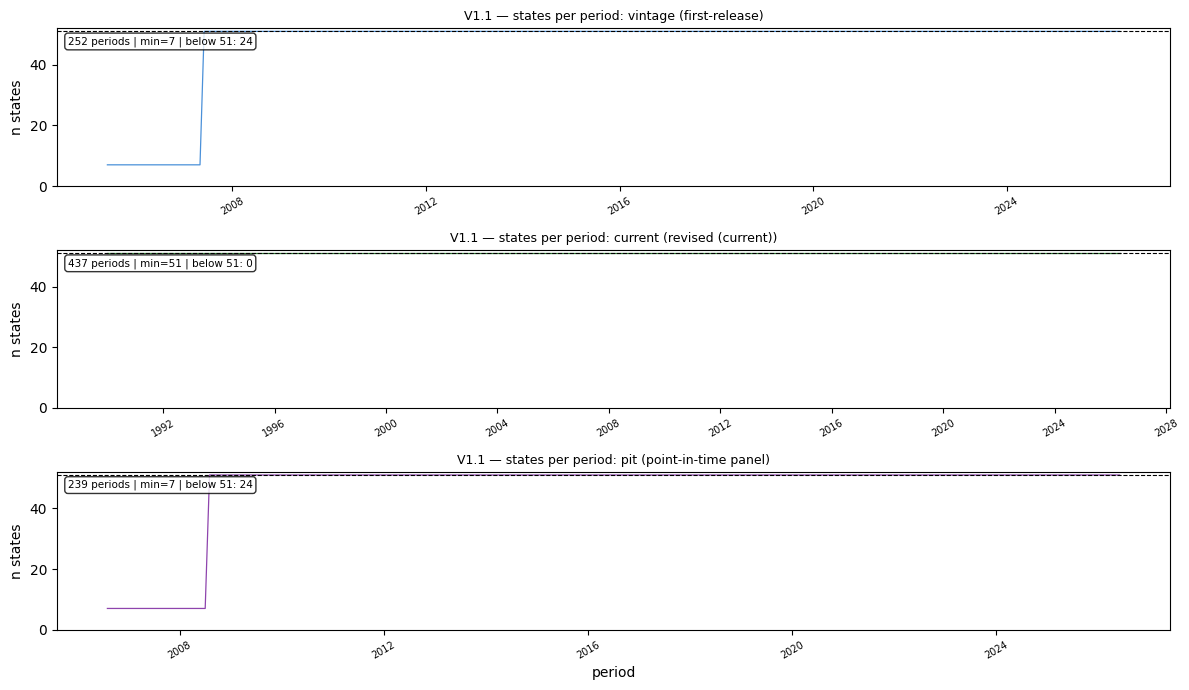


V1.1 — periods with < 51 states (all dates):

  vintage (first-release): 24 period(s)
    2005-06-01 00:00:00  (7 states)
    2005-07-01 00:00:00  (7 states)
    2005-08-01 00:00:00  (7 states)
    2005-09-01 00:00:00  (7 states)
    2005-10-01 00:00:00  (7 states)
    2005-11-01 00:00:00  (7 states)
    2005-12-01 00:00:00  (7 states)
    2006-01-01 00:00:00  (7 states)
    2006-02-01 00:00:00  (7 states)
    2006-03-01 00:00:00  (7 states)
    2006-04-01 00:00:00  (7 states)
    2006-05-01 00:00:00  (7 states)
    2006-06-01 00:00:00  (7 states)
    2006-07-01 00:00:00  (7 states)
    2006-08-01 00:00:00  (7 states)
    2006-09-01 00:00:00  (7 states)
    2006-10-01 00:00:00  (7 states)
    2006-11-01 00:00:00  (7 states)
    2006-12-01 00:00:00  (7 states)
    2007-01-01 00:00:00  (7 states)
    2007-02-01 00:00:00  (7 states)
    2007-03-01 00:00:00  (7 states)
    2007-04-01 00:00:00  (7 states)
    2007-05-01 00:00:00  (7 states)

  current (revised (current)): 0 period(s)
    (

In [9]:
# V1.1 — count unique states per dataset, then plot states reporting each period
N_EXPECTED = 51
_DATASETS = [
    ("vintage", df_v, "obs_date",  "#4a90d9", "first-release"),
    ("current", sa_c, "obs_date",  "#2e7d32", "revised (current)"),
    ("pit",     pit,  "as_of_date", "#8e44ad", "point-in-time panel"),
]
n_states_tbl = {name: df["state"].nunique() for name, df, _, _, _ in _DATASETS}
print("V1.1 — unique states per table (criterion: 51 everywhere):")
for name, n in n_states_tbl.items():
    print(f"  {name:8s}  {n:2d}  [{'OK' if n == N_EXPECTED else 'MISSING'}]")

_labels = [f"{n}\n({tag})" for n, _, _, _, tag in _DATASETS]
_counts = [n_states_tbl[n] for n, _, _, _, _ in _DATASETS]
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _counts, color=["#4a90d9" if n == N_EXPECTED else "#d94a4a" for n in _counts], width=0.55)
ax.axhline(N_EXPECTED, color="black", ls="--", lw=1, label=f"expected = {N_EXPECTED}")
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("unique states"); ax.set_ylim(0, N_EXPECTED + 2)
ax.set_title("V1.1 — unique states present in each table")
for bar, n in zip(bars, _counts):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 0.3, str(n), ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

per_period_stats = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, (name, df, date_col, color, tag) in zip(axes, _DATASETS):
    per = df.groupby(date_col)["state"].nunique().sort_index()
    per_period_stats[name] = per
    ax.plot(per.index, per.values, color=color, lw=0.9)
    ax.axhline(N_EXPECTED, color="black", ls="--", lw=0.8)
    ax.set_ylabel("n states"); ax.set_ylim(0, N_EXPECTED + 1)
    ax.set_title(f"V1.1 — states per period: {name} ({tag})", fontsize=9)
    ax.text(0.01, 0.95, f"{len(per):,} periods | min={per.min()} | below {N_EXPECTED}: {int((per < N_EXPECTED).sum())}",
            transform=ax.transAxes, va="top", fontsize=7.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period"); plt.tight_layout(); plt.show()

print(f"\nV1.1 — periods with < {N_EXPECTED} states (all dates):")
for name, _, _, _, tag in _DATASETS:
    incomplete = per_period_stats[name][per_period_stats[name] < N_EXPECTED]
    print(f"\n  {name} ({tag}): {len(incomplete):,} period(s)")
    print("    (none)" if incomplete.empty else "\n".join(f"    {dt}  ({int(n)} states)" for dt, n in incomplete.items()))

## V1.2 — Count and plot (state, month) keys per dataset

V1.2 — (state, month) key integrity (criterion: 0 duplicate rows):
  vintage   rows=11,796  unique keys=11,796  dup rows=0  [OK]  key=(state, obs_date) (first-release)
  current   rows=22,287  unique keys=22,287  dup rows=0  [OK]  key=(state, obs_date) (revised (current))
  pit       rows=11,133  unique keys=11,133  dup rows=0  [OK]  key=(as_of_date, state) (point-in-time panel)


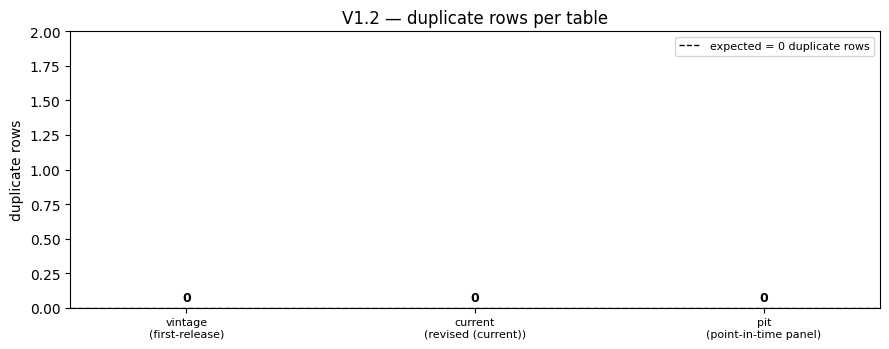

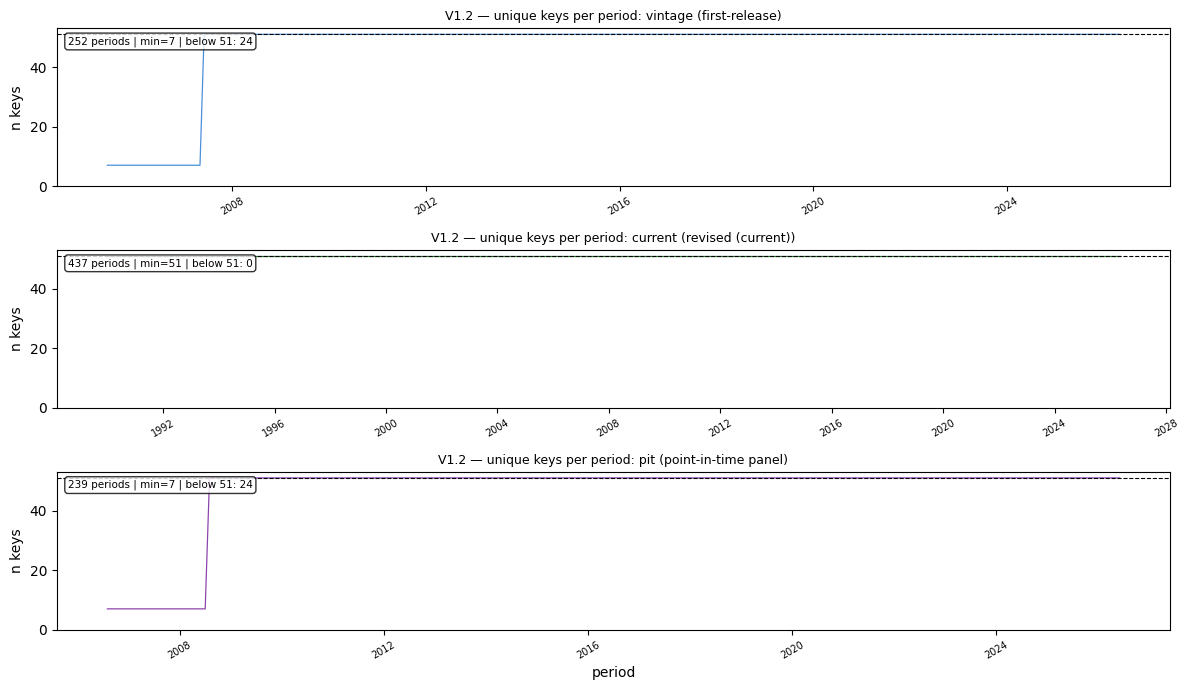


V1.2 — duplicate key instances (all):
  vintage (first-release): 0 duplicate row(s)  (none)
  current (revised (current)): 0 duplicate row(s)  (none)
  pit (point-in-time panel): 0 duplicate row(s)  (none)


In [10]:
# V1.2 — count and plot (state, month) keys per dataset (single validated series: SA nonfarm)
_DATASETS_V12 = [
    ("vintage", df_v, "obs_date",  ["state", "obs_date"],    51, "#4a90d9", "first-release"),
    ("current", sa_c, "obs_date",  ["state", "obs_date"],    51, "#2e7d32", "revised (current)"),
    ("pit",     pit,  "as_of_date", ["as_of_date", "state"], 51, "#8e44ad", "point-in-time panel"),
]
_key_stats = {}
for name, df, _, key_cols, _, _, _ in _DATASETS_V12:
    dm = df.duplicated(key_cols, keep=False)
    _key_stats[name] = {"rows": len(df), "unique": df.drop_duplicates(key_cols).shape[0], "dup_rows": int(dm.sum())}
print("V1.2 — (state, month) key integrity (criterion: 0 duplicate rows):")
for name, _, _, key_cols, _, _, tag in _DATASETS_V12:
    s = _key_stats[name]; kl = "(as_of_date, state)" if "as_of_date" in key_cols else "(state, obs_date)"
    print(f"  {name:8s}  rows={s['rows']:,}  unique keys={s['unique']:,}  dup rows={s['dup_rows']}  [{'OK' if s['dup_rows']==0 else 'DUP'}]  key={kl} ({tag})")

_labels = [f"{n}\n({tag})" for n, _, _, _, _, _, tag in _DATASETS_V12]
_dups = [_key_stats[n]["dup_rows"] for n, _, _, _, _, _, _ in _DATASETS_V12]
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _dups, color=["#2e7d32" if d == 0 else "#d94a4a" for d in _dups], width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0 duplicate rows")
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("duplicate rows"); ax.set_ylim(0, max(_dups + [1]) + 1); ax.set_title("V1.2 — duplicate rows per table")
for bar, d in zip(bars, _dups):
    ax.text(bar.get_x() + bar.get_width() / 2, d + 0.05, str(d), ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, (name, df, date_col, key_cols, expected, color, tag) in zip(axes, _DATASETS_V12):
    per = df.drop_duplicates(key_cols).groupby(date_col).size().sort_index()
    ax.plot(per.index, per.values, color=color, lw=0.9); ax.axhline(expected, color="black", ls="--", lw=0.8)
    ax.set_ylabel("n keys"); ax.set_ylim(0, expected + 2)
    ax.set_title(f"V1.2 — unique keys per period: {name} ({tag})", fontsize=9)
    ax.text(0.01, 0.95, f"{len(per):,} periods | min={per.min()} | below {expected}: {int((per < expected).sum())}",
            transform=ax.transAxes, va="top", fontsize=7.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period"); plt.tight_layout(); plt.show()

print("\nV1.2 — duplicate key instances (all):")
for name, df, _, key_cols, _, _, tag in _DATASETS_V12:
    dm = df.duplicated(key_cols, keep=False)
    print(f"  {name} ({tag}): {int(dm.sum())} duplicate row(s)" + ("" if dm.any() else "  (none)"))

## V1.3 — Count and plot nulls in the key fields

V1.3 — nulls in key fields (criterion: 0 nulls anywhere):

  vintage (first-release): 0 null(s)  [OK]
    state                   0
    obs_date                0
    first_release_date      0
    value_first_release     0

  current (revised (current)): 0 null(s)  [OK]
    state                   0
    obs_date                0
    value_current           0

  pit (point-in-time panel): 0 null(s)  [OK]
    as_of_date              0
    state                   0


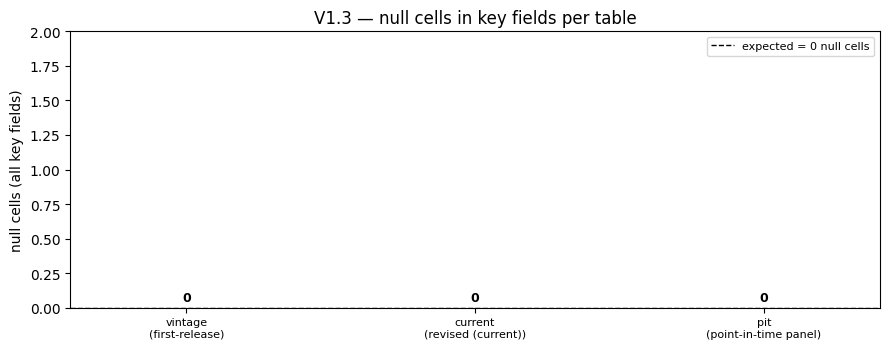

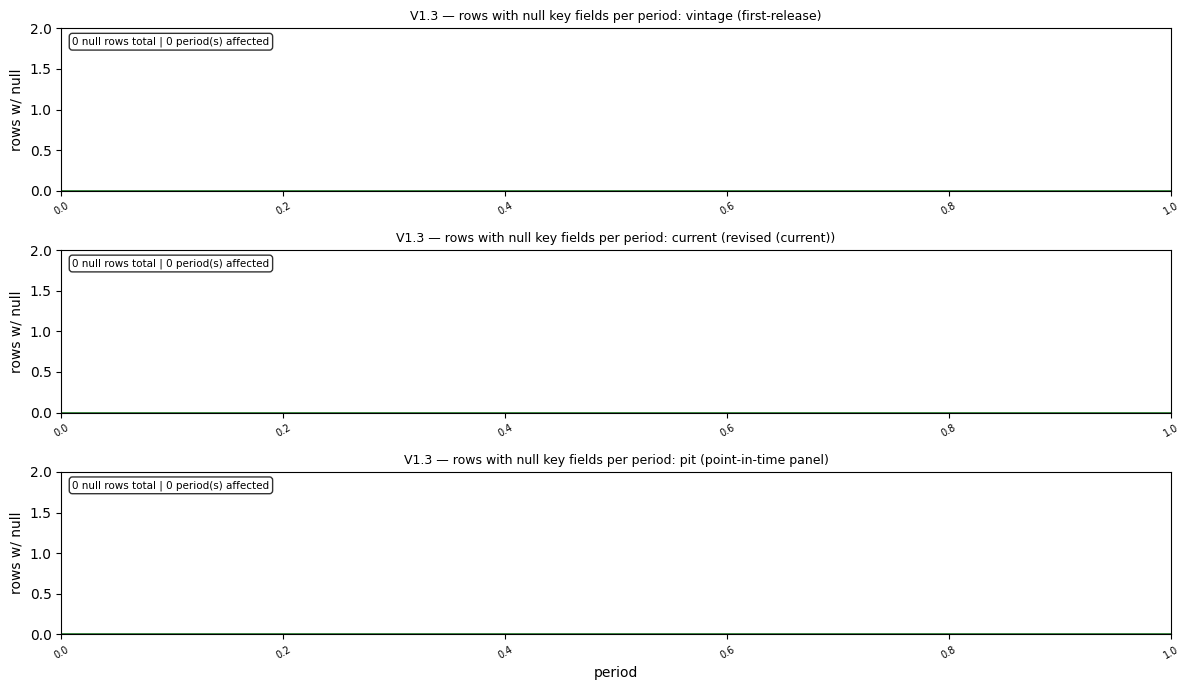


V1.3 — rows with null key fields (all):
  vintage (first-release): 0 row(s)  (none)
  current (revised (current)): 0 row(s)  (none)
  pit (point-in-time panel): 0 row(s)  (none)


In [11]:
# V1.3 — count and plot nulls in key fields per dataset
_KEY_FIELDS = {
    "vintage": ["state", "obs_date", "first_release_date", "value_first_release"],
    "current": ["state", "obs_date", "value_current"],
    "pit":     ["as_of_date", "state"],
}
_DATE_COL = {"vintage": "obs_date", "current": "obs_date", "pit": "as_of_date"}
_COLORS = {"vintage": "#4a90d9", "current": "#2e7d32", "pit": "#8e44ad"}
_TAGS = {"vintage": "first-release", "current": "revised (current)", "pit": "point-in-time panel"}
_DFS = {"vintage": df_v, "current": sa_c, "pit": pit}
_null_by_field = {n: _DFS[n][f].isna().sum() for n, f in _KEY_FIELDS.items()}
_null_rows = {n: int(_DFS[n][f].isna().any(axis=1).sum()) for n, f in _KEY_FIELDS.items()}

print("V1.3 — nulls in key fields (criterion: 0 nulls anywhere):")
for name, fields in _KEY_FIELDS.items():
    tot = int(_DFS[name][fields].isna().sum().sum())
    print(f"\n  {name} ({_TAGS[name]}): {tot} null(s)  [{'OK' if tot == 0 else 'NULL'}]")
    for field, n in _null_by_field[name].items():
        print(f"    {field:22s}  {int(n):,}")

_labels = [f"{n}\n({_TAGS[n]})" for n in _KEY_FIELDS]
_totals = [int(_null_by_field[n].sum()) for n in _KEY_FIELDS]
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _totals, color=["#2e7d32" if t == 0 else "#d94a4a" for t in _totals], width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0 null cells")
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("null cells (all key fields)"); ax.set_ylim(0, max(_totals + [1]) + 1)
ax.set_title("V1.3 — null cells in key fields per table")
for bar, t in zip(bars, _totals):
    ax.text(bar.get_x() + bar.get_width() / 2, t + 0.05, str(t), ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, name in zip(axes, _KEY_FIELDS):
    df = _DFS[name]; per = df.loc[df[_KEY_FIELDS[name]].isna().any(axis=1)].groupby(_DATE_COL[name]).size().sort_index()
    ax.plot(per.index, per.values, color=_COLORS[name], lw=0.9) if len(per) else ax.axhline(0, color="#2e7d32", lw=2)
    ax.set_ylabel("rows w/ null"); ax.set_ylim(0, max(per.max() if len(per) else 0, 1) + 1)
    ax.set_title(f"V1.3 — rows with null key fields per period: {name} ({_TAGS[name]})", fontsize=9)
    ax.text(0.01, 0.95, f"{_null_rows[name]:,} null rows total | {len(per):,} period(s) affected",
            transform=ax.transAxes, va="top", fontsize=7.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period"); plt.tight_layout(); plt.show()

print("\nV1.3 — rows with null key fields (all):")
for name in _KEY_FIELDS:
    bad = _DFS[name][_DFS[name][_KEY_FIELDS[name]].isna().any(axis=1)]
    print(f"  {name} ({_TAGS[name]}): {len(bad):,} row(s)" + ("" if len(bad) else "  (none)"))

## V1.4 — Values finite and strictly positive

V1.4 — level finite and strictly positive (criterion: 0 bad rows):
  vintage   bad rows=0  [OK]  observed [249, 18,181]k  (first-release)
  current   bad rows=0  [OK]  observed [196, 18,166]k  (revised (current))


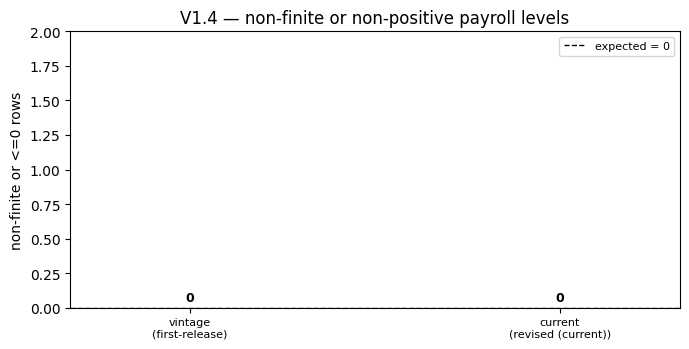

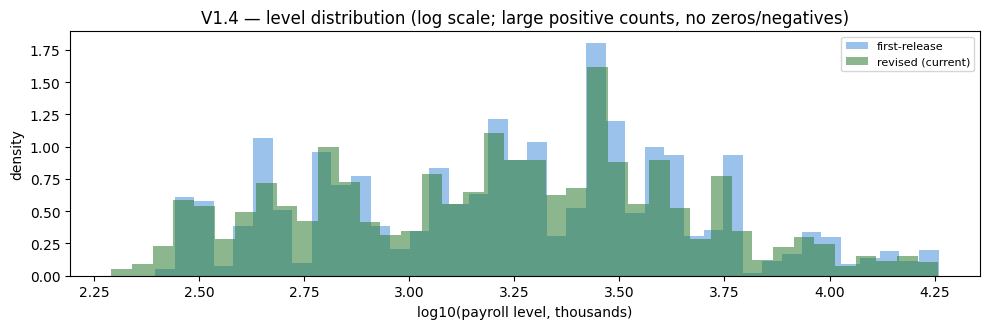

In [12]:
# V1.4 — payroll level is a strictly-positive count; every value finite and > 0
_VAL_COLS = {
    "vintage": ("value_first_release", df_v, "#4a90d9", "first-release"),
    "current": ("value_current",       sa_c, "#2e7d32", "revised (current)"),
}
def _bad_mask(series):
    return ~series.apply(lambda x: isinstance(x, (int, float, np.integer, np.floating)) and np.isfinite(x) and x > 0)
_bad = {}
for name, (col, df, color, tag) in _VAL_COLS.items():
    _bad[name] = df.loc[_bad_mask(df[col]), ["state", "obs_date", col]].rename(columns={col: "value"})

print("V1.4 — level finite and strictly positive (criterion: 0 bad rows):")
for name, (col, df, _, tag) in _VAL_COLS.items():
    print(f"  {name:8s}  bad rows={len(_bad[name]):,}  [{'OK' if len(_bad[name]) == 0 else 'BAD'}]  "
          f"observed [{df[col].min():,.0f}, {df[col].max():,.0f}]k  ({tag})")

_labels = [f"{n}\n({t})" for n, (_, _, _, t) in _VAL_COLS.items()]
_counts = [len(_bad[n]) for n in _VAL_COLS]
fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(range(len(_labels)), _counts, color=["#2e7d32" if c == 0 else "#d94a4a" for c in _counts], width=0.5)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0")
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("non-finite or <=0 rows"); ax.set_ylim(0, max(_counts + [1]) + 1)
ax.set_title("V1.4 — non-finite or non-positive payroll levels")
for bar, c in zip(bars, _counts):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 0.05, str(c), ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

# level distribution (log scale) — confirms the large-positive-count character
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(np.log10(df_v["value_first_release"]), bins=40, alpha=0.55, color="#4a90d9", label="first-release", density=True)
ax.hist(np.log10(sa_c["value_current"]), bins=40, alpha=0.55, color="#2e7d32", label="revised (current)", density=True)
ax.set_xlabel("log10(payroll level, thousands)"); ax.set_ylabel("density")
ax.set_title("V1.4 — level distribution (log scale; large positive counts, no zeros/negatives)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## V1.4b — Levels a plausible employment magnitude (digit-error / scale guard)

V1.4b — level magnitude sanity (criterion: no month < 40% or > 250% of its state median):
  flagged state-months: 0   smallest (min / median) ratio across states: 0.53
  (none — every level stays within a plausible band of its state norm)


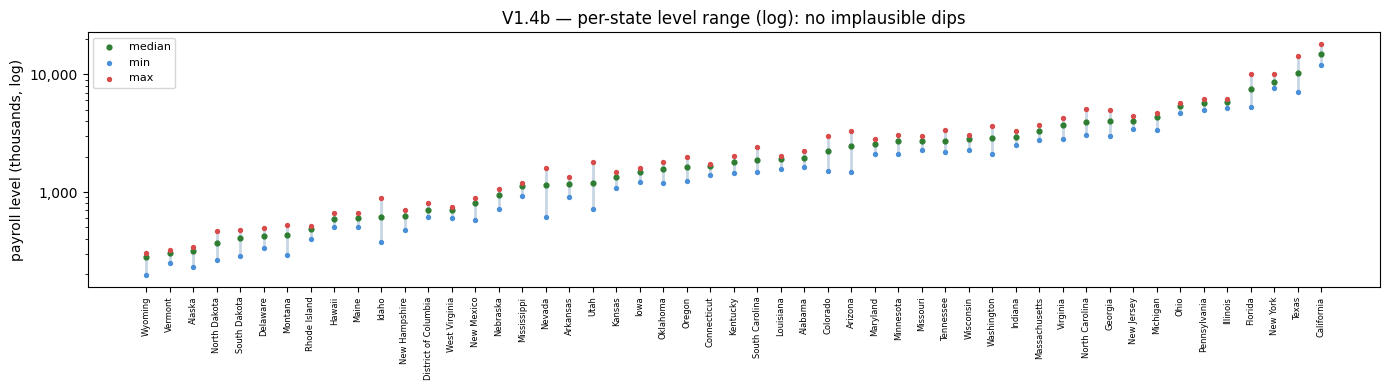

In [13]:
# V1.4b — a level series should never dip far below its own norm; a value << the state's median
# would signal a dropped-digit / units error. Flag any month < 40% or > 250% of the state's median.
LO_FRAC, HI_FRAC = 0.40, 2.50
_flags = []
_state_med = {}
for state, g in sa_c.groupby("state"):
    med = g["value_current"].median(); _state_med[state] = med
    bad = g[(g["value_current"] < LO_FRAC * med) | (g["value_current"] > HI_FRAC * med)]
    for _, r in bad.iterrows():
        _flags.append({"state": state, "obs_date": r["obs_date"].date(), "value": r["value_current"],
                       "state_median": round(med, 1), "ratio": round(r["value_current"] / med, 2)})
_flags = pd.DataFrame(_flags)
min_ratio = (sa_c.groupby("state")["value_current"].min() / pd.Series(_state_med)).min()

print(f"V1.4b — level magnitude sanity (criterion: no month < {LO_FRAC:.0%} or > {HI_FRAC:.0%} of its state median):")
print(f"  flagged state-months: {len(_flags)}   smallest (min / median) ratio across states: {min_ratio:.2f}")
if len(_flags):
    print(_flags.sort_values("ratio").to_string(index=False))
else:
    print("  (none — every level stays within a plausible band of its state norm)")

# per-state level range on a log scale (min / median / max)
_rng = sa_c.groupby("state")["value_current"].agg(["min", "median", "max"]).sort_values("median")
fig, ax = plt.subplots(figsize=(14, 4))
x = range(len(_rng))
ax.vlines(x, _rng["min"], _rng["max"], color="#c8d6e5", lw=2, zorder=1)
ax.scatter(x, _rng["median"], color="#2e7d32", s=12, zorder=2, label="median")
ax.scatter(x, _rng["min"], color="#4a90d9", s=8, zorder=2, label="min")
ax.scatter(x, _rng["max"], color="#d94a4a", s=8, zorder=2, label="max")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(_rng.index, rotation=90, fontsize=6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylabel("payroll level (thousands, log)"); ax.set_title("V1.4b — per-state level range (log): no implausible dips")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

df_v missing cells — by obs_date: 1,056 of 12,852 (8.22%)
df_v missing cells — by first_release_date: 1,056 of 12,750 (8.28%)


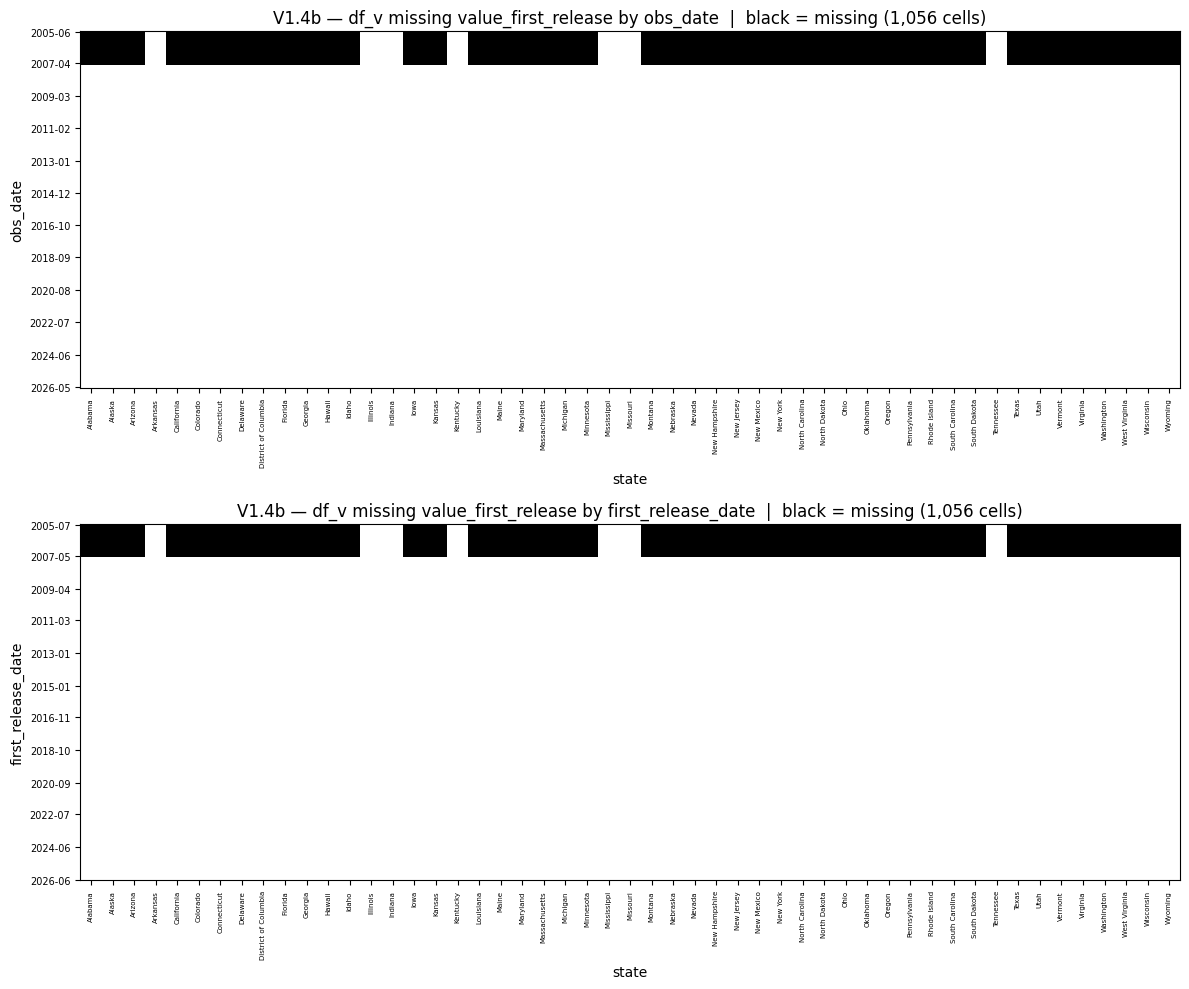

In [30]:
# V1.4b — df_v missing-value heatmaps (obs_date vs first_release_date grids)
_states_sorted = sorted(df_v["state"].unique())

_pivots = [
    ("obs_date", df_v.pivot_table(index="obs_date", columns="state", values="value_first_release")),
    ("first_release_date", df_v.pivot_table(index="first_release_date", columns="state", values="value_first_release")),
]

for label, wide in _pivots:
    wide = wide.reindex(columns=_states_sorted).sort_index()
    missing = wide.isna()
    print(f"df_v missing cells — by {label}: {int(missing.values.sum()):,} of {missing.size:,} "
          f"({missing.values.mean():.2%})")

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, (label, wide) in zip(axes, _pivots):
    wide = wide.reindex(columns=_states_sorted).sort_index()
    missing = wide.isna()
    cal = missing.index
    n_miss = int(missing.values.sum())
    ax.imshow(missing.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
    ax.set_xticks(range(len(_states_sorted)))
    ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
    _yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
    ax.set_yticks(_yt)
    ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
    ax.set_xlabel("state")
    ax.set_ylabel(label)
    ax.set_title(f"V1.4b — df_v missing value_first_release by {label}  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()


sa_c missing cells — by obs_date: 0 of 22,287 (0.00%)


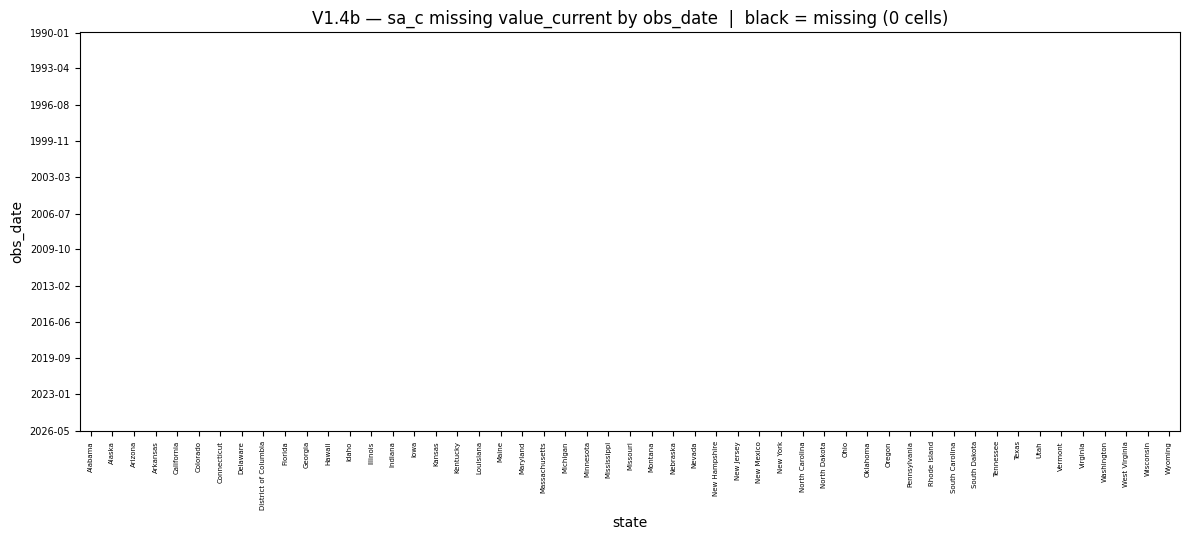

In [31]:
# V1.4b — sa_c missing-value heatmap (obs_date grid, revised current history)
_states_sorted = sorted(sa_c["state"].unique())

wide_c = sa_c.pivot_table(index="obs_date", columns="state", values="value_current")
wide_c = wide_c.reindex(columns=_states_sorted).sort_index()
missing_c = wide_c.isna()

print(f"sa_c missing cells — by obs_date: {int(missing_c.values.sum()):,} of {missing_c.size:,} "
      f"({missing_c.values.mean():.2%})")

fig, ax = plt.subplots(figsize=(12, 5.5))
cal = missing_c.index
n_miss = int(missing_c.values.sum())
ax.imshow(missing_c.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(_states_sorted)))
ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
_yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
ax.set_yticks(_yt)
ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
ax.set_xlabel("state")
ax.set_ylabel("obs_date")
ax.set_title(f"V1.4b — sa_c missing value_current by obs_date  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()


pit missing cells — nfp_t0 by as_of_date: 1,056 of 12,189 (8.66%)


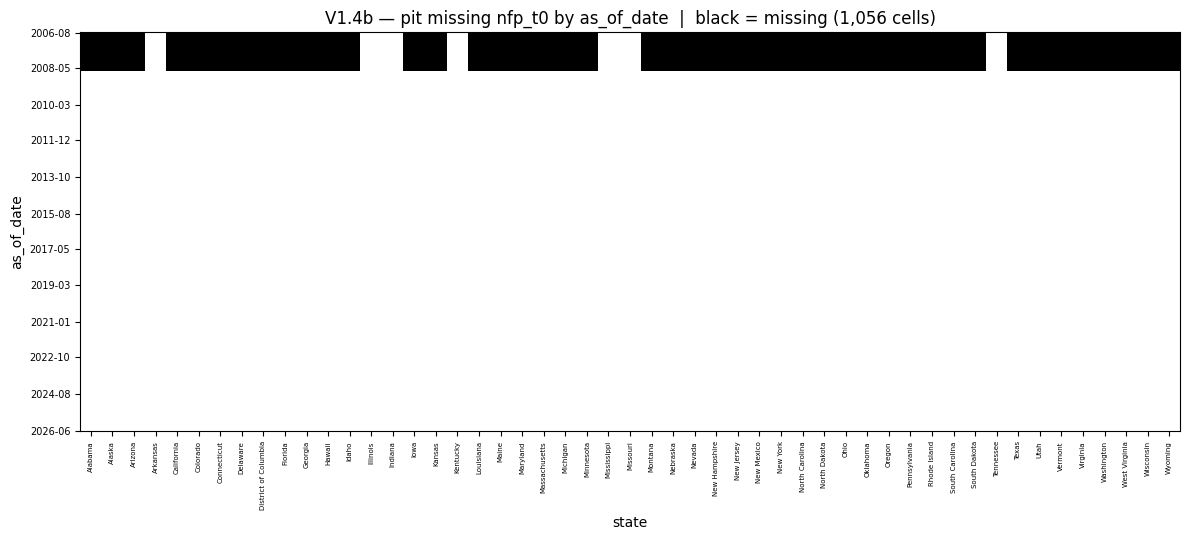

In [32]:
# V1.4b — pit missing-value heatmap (as_of_date grid, nfp_t0)
_states_sorted = sorted(pit["state"].unique())

wide_pit = pit.pivot_table(index="as_of_date", columns="state", values="nfp_t0")
wide_pit = wide_pit.reindex(columns=_states_sorted).sort_index()
missing_pit = wide_pit.isna()

print(f"pit missing cells — nfp_t0 by as_of_date: {int(missing_pit.values.sum()):,} of {missing_pit.size:,} "
      f"({missing_pit.values.mean():.2%})")

fig, ax = plt.subplots(figsize=(12, 5.5))
cal = missing_pit.index
n_miss = int(missing_pit.values.sum())
ax.imshow(missing_pit.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(_states_sorted)))
ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
_yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
ax.set_yticks(_yt)
ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
ax.set_xlabel("state")
ax.set_ylabel("as_of_date")
ax.set_title(f"V1.4b — pit missing nfp_t0 by as_of_date  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()


## V1.5 — Row counts per state (fetch truncation check)

V1.5 — row counts per state, NFP current history
  (criterion: max - min <= 3 months; spread=0)
  min=437  max=437  median=437  n_states=51

V1.5 — rows per state (sorted ascending):
               state  n_rows  vs_median
             Alabama     437        0.0
            Nebraska     437        0.0
              Nevada     437        0.0
       New Hampshire     437        0.0
          New Jersey     437        0.0
          New Mexico     437        0.0
            New York     437        0.0
      North Carolina     437        0.0
        North Dakota     437        0.0
                Ohio     437        0.0
            Oklahoma     437        0.0
             Montana     437        0.0
              Oregon     437        0.0
        Rhode Island     437        0.0
      South Carolina     437        0.0
        South Dakota     437        0.0
           Tennessee     437        0.0
               Texas     437        0.0
                Utah     437        0.0
             Verm

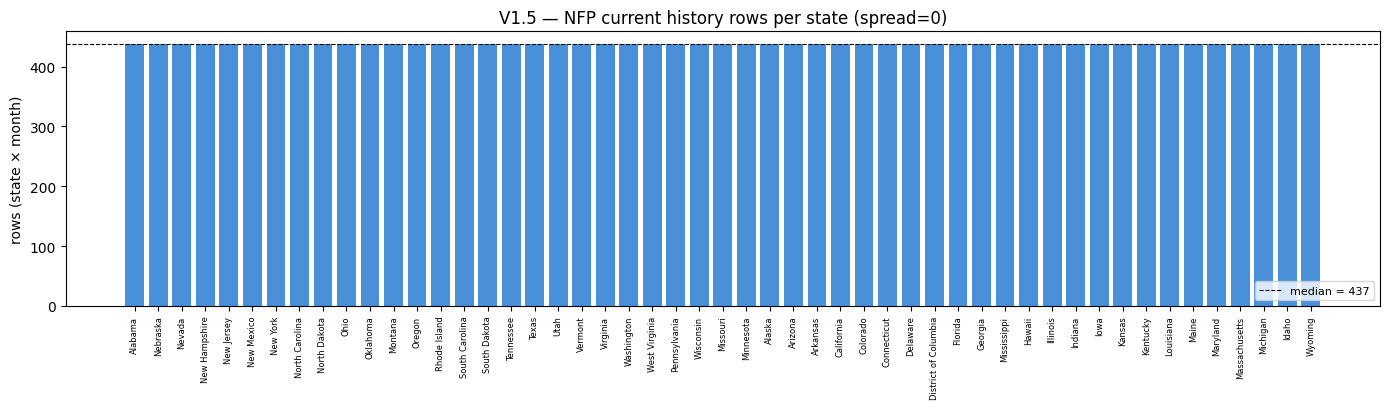

In [14]:
# V1.5 — row counts per state (fetch truncation check), revised (current) SA history
rc = sa_c.groupby("state").size().sort_values()
rc_min, rc_max, rc_median = int(rc.min()), int(rc.max()), float(rc.median())
spread = rc_max - rc_min
print("V1.5 — row counts per state, NFP current history")
print(f"  (criterion: max - min <= 3 months; spread={spread})")
print(f"  min={rc_min}  max={rc_max}  median={rc_median:.0f}  n_states={len(rc)}")
_rc_tbl = rc.reset_index(name="n_rows"); _rc_tbl["vs_median"] = _rc_tbl["n_rows"] - rc_median
print("\nV1.5 — rows per state (sorted ascending):")
print(_rc_tbl.to_string(index=False))
_out = _rc_tbl[_rc_tbl["vs_median"].abs() > 3]
print(f"\nV1.5 — states >3 months from median ({len(_out)}):")
print("  (none)" if _out.empty else _out.to_string(index=False))

_states = rc.index.tolist()
fig, ax = plt.subplots(figsize=(14, 4.2))
ax.bar(range(len(_states)), rc.values, color=["#d94a4a" if abs(v - rc_median) > 3 else "#4a90d9" for v in rc.values], width=0.8)
ax.axhline(rc_median, color="black", ls="--", lw=0.8, label=f"median = {rc_median:.0f}")
ax.set_xticks(range(len(_states))); ax.set_xticklabels(_states, rotation=90, fontsize=6)
ax.set_ylabel("rows (state × month)"); ax.set_title(f"V1.5 — NFP current history rows per state (spread={spread})")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

## V2 — Calendar & frequency — *observation time: the month being measured*

The **observation clock**: `obs_date` stamps the reference month (FRED uses the 1st; the payroll counts the pay period containing the 12th). *What* the number measures — not when it was known (V3).

| Check | Question it answers |
|---|---|
| V2.1 | Do all observation dates follow the monthly (month-start) convention? |
| V2.2a | Are there missing months shared by all states (systematic BLS holes)? |
| V2.2b | Are there per-state (idiosyncratic) missing months? |
| V2.3 | Do all states cover the same window (balanced panel)? |

## V2.1 — Monthly month-start convention

V2.1 — obs_date is the 1st of the month (criterion: 100% day == 1):
  vintage  (first-release):  non-month-start rows=0  [OK]
  current  (revised (current)):  non-month-start rows=0  [OK]


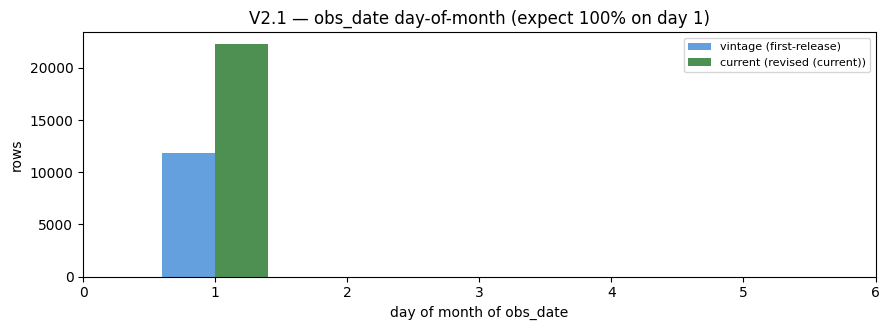

[PASS] V2.1   All obs_date are month-starts (monthly reference convention)  |  vintage=0, current=0 non-month-start  (criterion: == 0)


In [15]:
# V2.1 — every obs_date is a month-start (day == 1)
_DS = [("vintage", df_v, "#4a90d9", "first-release"), ("current", sa_c, "#2e7d32", "revised (current)")]
_bad = {name: df.loc[df["obs_date"].dt.day != 1, ["state", "obs_date"]].drop_duplicates() for name, df, _, _ in _DS}
print("V2.1 — obs_date is the 1st of the month (criterion: 100% day == 1):")
for name, df, _, tag in _DS:
    print(f"  {name:8s} ({tag}):  non-month-start rows={len(_bad[name])}  [{'OK' if len(_bad[name]) == 0 else 'FAIL'}]")

fig, ax = plt.subplots(figsize=(9, 3.4))
w = 0.4
for i, (name, df, color, tag) in enumerate(_DS):
    dom = df["obs_date"].dt.day.value_counts().reindex(range(1, 32), fill_value=0).sort_index()
    ax.bar(np.arange(1, 32) + (i - 0.5) * w, dom.values, w, color=color, alpha=0.85, label=f"{name} ({tag})")
ax.set_xlim(0, 6); ax.set_xlabel("day of month of obs_date"); ax.set_ylabel("rows")
ax.set_title("V2.1 — obs_date day-of-month (expect 100% on day 1)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

add_check("V2", "V2.1", "All obs_date are month-starts (monthly reference convention)",
          "PASS" if all(len(_bad[n]) == 0 for n, *_ in _DS) else "FAIL",
          metric=f"vintage={len(_bad['vintage'])}, current={len(_bad['current'])} non-month-start", threshold="== 0")

## V2.2a — Missing months shared by all states (systematic BLS holes)

V2.2a — systematic (shared) missing months (criterion: documented BLS-wide holes):
  systematic months: 0


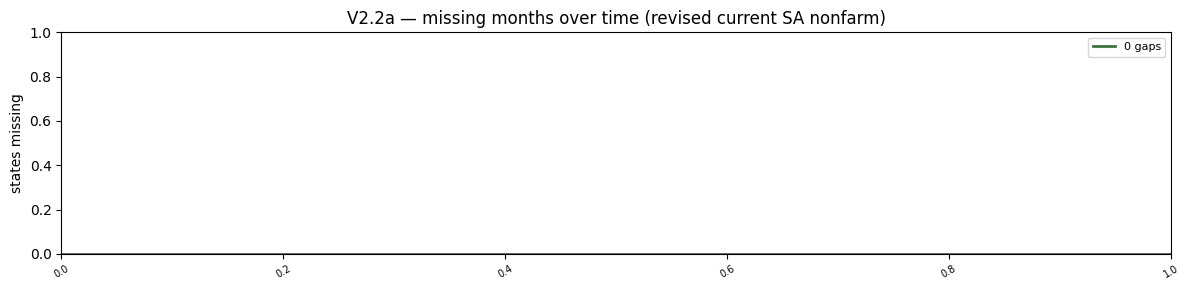

[PASS] V2.2a  Systematic (shared) missing months  |  none  (criterion: documented; shared BLS-wide holes tolerated as WARN)


In [16]:
# V2.2a — interior monthly gaps; a gap shared by (nearly) all states is a systematic BLS event
miss_by_month = {}
for state, g in sa_c.groupby("state"):
    cal = pd.date_range(g["obs_date"].min(), g["obs_date"].max(), freq="MS")
    for d in cal.difference(g["obs_date"]):
        miss_by_month[d] = miss_by_month.get(d, 0) + 1
systematic = {d: n for d, n in miss_by_month.items() if n >= 45}
idiosyncratic = {d: n for d, n in miss_by_month.items() if n < 45}

print("V2.2a — systematic (shared) missing months (criterion: documented BLS-wide holes):")
print(f"  systematic months: {len(systematic)}")
for d in sorted(systematic):
    print(f"    {d.date()}  ({systematic[d]} states missing)")

fig, ax = plt.subplots(figsize=(12, 3.0))
if miss_by_month:
    s = pd.Series(miss_by_month).sort_index()
    ax.bar(s.index, s.values, color=["#d94a4a" if v >= 45 else "#f0ad4e" for v in s.values], width=20)
    ax.axhline(45, color="black", ls=":", lw=0.8, label="45-state systematic threshold")
else:
    ax.axhline(0, color="#2e7d32", lw=2, label="0 gaps")
ax.set_ylabel("states missing"); ax.set_title("V2.2a — missing months over time (revised current SA nonfarm)")
ax.legend(fontsize=8); ax.tick_params(axis="x", labelrotation=30, labelsize=7); plt.tight_layout(); plt.show()

add_check("V2", "V2.2a", "Systematic (shared) missing months",
          "PASS" if not systematic else "WARN",
          metric=(f"{len(systematic)} month(s) across all states: " + ", ".join(d.strftime("%Y-%m") for d in sorted(systematic))) if systematic else "none",
          threshold="documented; shared BLS-wide holes tolerated as WARN")

## V2.2b — Per-state (idiosyncratic) missing months

V2.2b — idiosyncratic missing months (criterion: == 0; each must be investigated):
  idiosyncratic months: 0
  (none — no per-state holes)


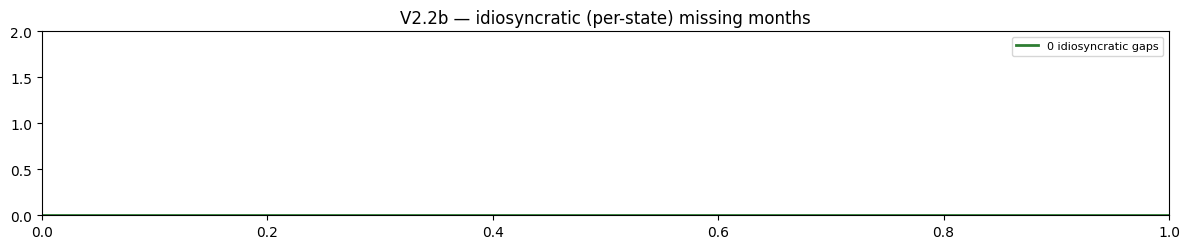

[PASS] V2.2b  Idiosyncratic (per-state) missing months  |  0 idiosyncratic month(s)  (criterion: == 0)


In [17]:
# V2.2b — idiosyncratic gaps (a single state failing to report a month)
print("V2.2b — idiosyncratic missing months (criterion: == 0; each must be investigated):")
print(f"  idiosyncratic months: {len(idiosyncratic)}")
if idiosyncratic:
    _rows = []
    for state, g in sa_c.groupby("state"):
        cal = pd.date_range(g["obs_date"].min(), g["obs_date"].max(), freq="MS")
        for d in cal.difference(g["obs_date"]):
            if miss_by_month[d] < 45:
                _rows.append({"state": state, "missing_month": d.date()})
    print(pd.DataFrame(_rows).sort_values(["missing_month", "state"]).to_string(index=False))
else:
    print("  (none — no per-state holes)")

fig, ax = plt.subplots(figsize=(12, 2.6))
if not idiosyncratic:
    ax.axhline(0, color="#2e7d32", lw=2, label="0 idiosyncratic gaps")
ax.set_ylim(0, 2); ax.set_title("V2.2b — idiosyncratic (per-state) missing months"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

add_check("V2", "V2.2b", "Idiosyncratic (per-state) missing months",
          "PASS" if not idiosyncratic else "WARN",
          metric=f"{len(idiosyncratic)} idiosyncratic month(s)", threshold="== 0")

## V2.3 — Panel window alignment across states

V2.3 — panel edges across states, revised (current) SA nonfarm
  (criterion: start spread == 0, end spread <= 1 month)
  start spread: 0m   end spread: 0m
  common balanced window: 1990-01-01 -> 2026-05-01

V2.3 — first/last obs_date per state:
                     first_month last_month  n_months
state                                                
Alabama               1990-01-01 2026-05-01       437
Nebraska              1990-01-01 2026-05-01       437
Nevada                1990-01-01 2026-05-01       437
New Hampshire         1990-01-01 2026-05-01       437
New Jersey            1990-01-01 2026-05-01       437
New Mexico            1990-01-01 2026-05-01       437
New York              1990-01-01 2026-05-01       437
North Carolina        1990-01-01 2026-05-01       437
North Dakota          1990-01-01 2026-05-01       437
Ohio                  1990-01-01 2026-05-01       437
Oklahoma              1990-01-01 2026-05-01       437
Montana               1990-01-01 2026-05-01       437

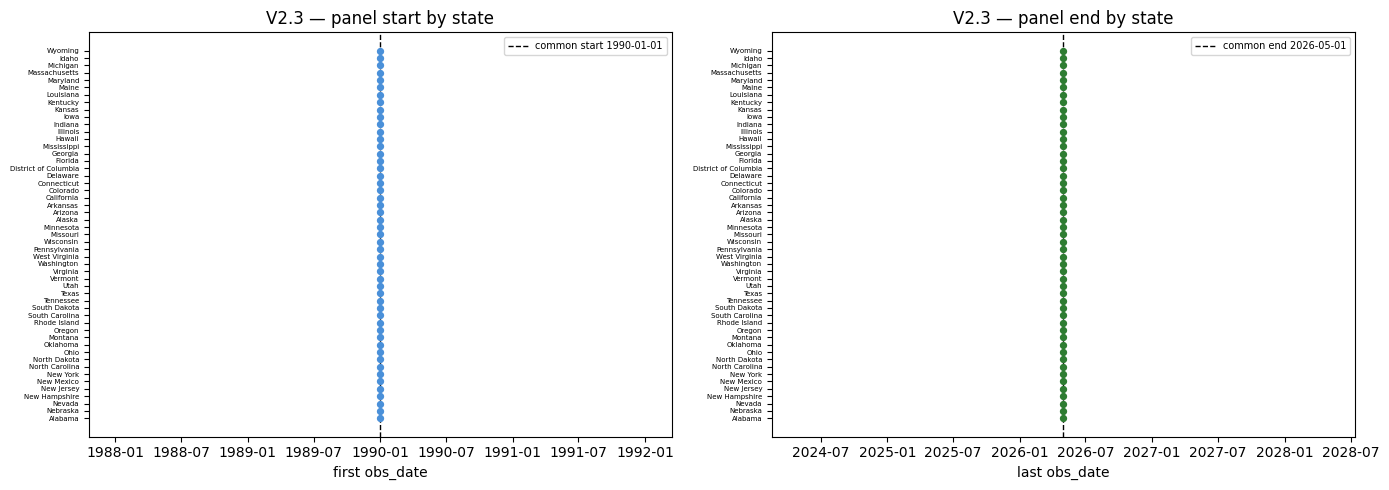

[PASS] V2.3   Panel edges aligned across states  |  start spread=0m, end spread=0m  (criterion: start==0, end<=1m)
       note: common window: 1990-01-01 -> 2026-05-01


In [18]:
# V2.3 — do all states cover the same window? (panel start/end spread)
_edges = (sa_c.groupby("state")["obs_date"].agg(first_month="min", last_month="max", n_months="count").sort_values("first_month"))
start_spread = int((_edges["first_month"].max() - _edges["first_month"].min()).days // 30)
end_spread = int((_edges["last_month"].max() - _edges["last_month"].min()).days // 30)
common_start, common_end = _edges["first_month"].max(), _edges["last_month"].min()

print("V2.3 — panel edges across states, revised (current) SA nonfarm")
print(f"  (criterion: start spread == 0, end spread <= 1 month)")
print(f"  start spread: {start_spread}m   end spread: {end_spread}m")
print(f"  common balanced window: {common_start.date()} -> {common_end.date()}")
print("\nV2.3 — first/last obs_date per state:")
print(_edges.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
states = _edges.index.tolist(); y = range(len(states))
axes[0].scatter(_edges["first_month"], y, c="#4a90d9", s=18, zorder=3)
axes[0].axvline(common_start, color="black", ls="--", lw=1, label=f"common start {common_start.date()}")
axes[0].set_yticks(y); axes[0].set_yticklabels(states, fontsize=5)
axes[0].set_xlabel("first obs_date"); axes[0].set_title("V2.3 — panel start by state"); axes[0].legend(fontsize=7)
axes[1].scatter(_edges["last_month"], y, c="#2e7d32", s=18, zorder=3)
axes[1].axvline(common_end, color="black", ls="--", lw=1, label=f"common end {common_end.date()}")
axes[1].set_yticks(y); axes[1].set_yticklabels(states, fontsize=5)
axes[1].set_xlabel("last obs_date"); axes[1].set_title("V2.3 — panel end by state"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

add_check("V2", "V2.3", "Panel edges aligned across states",
          "PASS" if start_spread == 0 and end_spread <= 1 else "WARN",
          metric=f"start spread={start_spread}m, end spread={end_spread}m",
          threshold="start==0, end<=1m", note=f"common window: {common_start.date()} -> {common_end.date()}")

## V3 — Point-in-time & release calendar — *information time: when the number became known*

The **information clock**. State payrolls are published in the monthly *State Employment and Unemployment* report — the same release as state U3 — ~50 days after the reference month, on a Friday, ~3 weeks after the national jobs report.

| Check | Question it answers |
|---|---|
| V3.1 | How far back can point-in-time be reconstructed? |
| V3.2 | Does the national vintage calendar match the jobs-report (Friday) schedule? |
| V3.3 | Is the state publication lag ~50 days? |
| V3.4 | Do state releases follow the national jobs report? |
| V3.5 | Is the publication-lag regime stable over time? |
| V3.6 | Do months become available in order (monotone frontier)? |
| V3.7 | Does the PIT panel contain any look-ahead? |

## V3.1 — How far back can point-in-time be reconstructed?

V3.1 — point-in-time reconstruction boundary (criterion: boundary documented):
  first ALFRED vintage:  2005-07-22
  obs_date span:         2005-06-01 -> 2026-05-01
  PIT as_of span:        2006-08-01 -> 2026-06-01

V3.1 — first vintage date per state:
               state first_vintage
            Missouri    2005-07-22
         Mississippi    2005-07-22
            Kentucky    2005-07-22
             Indiana    2005-07-22
           Tennessee    2005-07-22
            Illinois    2005-07-22
            Arkansas    2005-07-22
                Utah    2007-07-20
       West Virginia    2007-07-20
          New Jersey    2007-07-20
          New Mexico    2007-07-20
            New York    2007-07-20
      North Carolina    2007-07-20
        North Dakota    2007-07-20
                Ohio    2007-07-20
          Washington    2007-07-20
            Oklahoma    2007-07-20
              Oregon    2007-07-20
       New Hampshire    2007-07-20
        Pennsylvania    2007-07-20
        Rhod

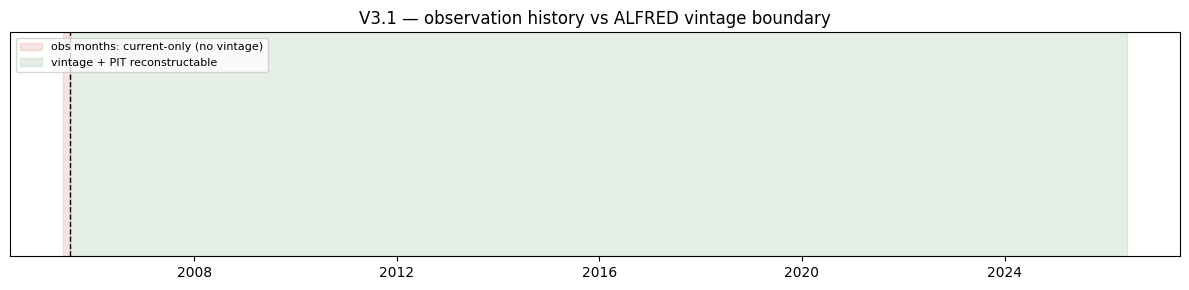

[WARN] V3.1   ALFRED vintage boundary identified  |  first vintage 2005-07-22  (criterion: documented)
       note: pre-boundary history exists only as current values: usable for trend estimation, NOT backtesting


In [19]:
# V3.1 — ALFRED vintage boundary
vint_start, vint_end = df_v["first_release_date"].min(), df_v["first_release_date"].max()
obs_min, obs_max = df_v["obs_date"].min(), df_v["obs_date"].max()
pit_start, pit_end = pit["as_of_date"].min(), pit["as_of_date"].max()
state_first_vint = df_v.groupby("state")["first_release_date"].min().sort_values()
print("V3.1 — point-in-time reconstruction boundary (criterion: boundary documented):")
print(f"  first ALFRED vintage:  {vint_start.date()}")
print(f"  obs_date span:         {obs_min.date()} -> {obs_max.date()}")
print(f"  PIT as_of span:        {pit_start.date()} -> {pit_end.date()}")
print("\nV3.1 — first vintage date per state:")
print(state_first_vint.reset_index(name="first_vintage").to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 3.0))
ax.axvspan(obs_min, vint_start, alpha=0.15, color="#d94a4a", label="obs months: current-only (no vintage)")
ax.axvspan(vint_start, pit_end, alpha=0.12, color="#2e7d32", label="vintage + PIT reconstructable")
ax.axvline(vint_start, color="black", ls="--", lw=1)
ax.set_yticks([]); ax.set_title("V3.1 — observation history vs ALFRED vintage boundary")
ax.legend(fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()

add_check("V3", "V3.1", "ALFRED vintage boundary identified", "WARN",
          metric=f"first vintage {vint_start.date()}", threshold="documented",
          note="pre-boundary history exists only as current values: usable for trend estimation, NOT backtesting")

## V3.2 — Does the national vintage calendar match the jobs-report (Friday) schedule?

V3.2 — national PAYEMS vintage calendar (criterion: Friday >= 80%):
    Mon    27  (3.2%)
    Tue    44  (5.1%)
    Wed    40  (4.7%)
    Thu    61  (7.1%)
    Fri   685  (79.9%)


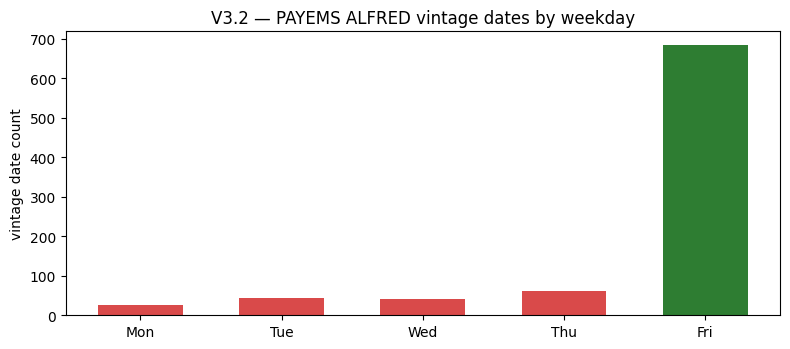

[WARN] V3.2   National PAYEMS vintages land on the jobs-report day (Friday)  |  Mon 3%, Tue 5%, Wed 5%, Thu 7%, Fri 80%  (criterion: Friday >= 80%)
       note: national Employment Situation is released the first Friday after the reference month


In [20]:
# V3.2 — national PAYEMS vintage dates land on the jobs-report day (Friday)
_WD = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
nat_wd = nat_vdates.dt.dayofweek.value_counts().sort_index()
fri_share = nat_wd.get(4, 0) / len(nat_vdates)
print("V3.2 — national PAYEMS vintage calendar (criterion: Friday >= 80%):")
for d, n in nat_wd.items():
    print(f"    {_WD[d]:3s}  {int(n):4d}  ({n/len(nat_vdates):.1%})")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar([_WD[d] for d in nat_wd.index], nat_wd.values, color=["#2e7d32" if d == 4 else "#d94a4a" for d in nat_wd.index], width=0.6)
ax.set_ylabel("vintage date count"); ax.set_title("V3.2 — PAYEMS ALFRED vintage dates by weekday")
plt.tight_layout(); plt.show()
add_check("V3", "V3.2", "National PAYEMS vintages land on the jobs-report day (Friday)",
          "PASS" if fri_share >= 0.80 else "WARN",
          metric=", ".join(f"{_WD[k]} {nat_wd.get(k,0)/len(nat_vdates):.0%}" for k in nat_wd.index if nat_wd.get(k,0)/len(nat_vdates) >= 0.01),
          threshold="Friday >= 80%", note="national Employment Situation is released the first Friday after the reference month")

## V3.3 — Is the state publication lag ~50 days?

V3.3 — state NFP publication lag (criterion: median in [40, 60] days):
                count  mean  std   min   25%   50%   75%    max
pub_lag_days  11796.0  52.5  9.0  45.0  48.0  50.0  53.0  101.0
  median=50d  (~1.7 months; released with state U3, ~3 weeks after the national report)


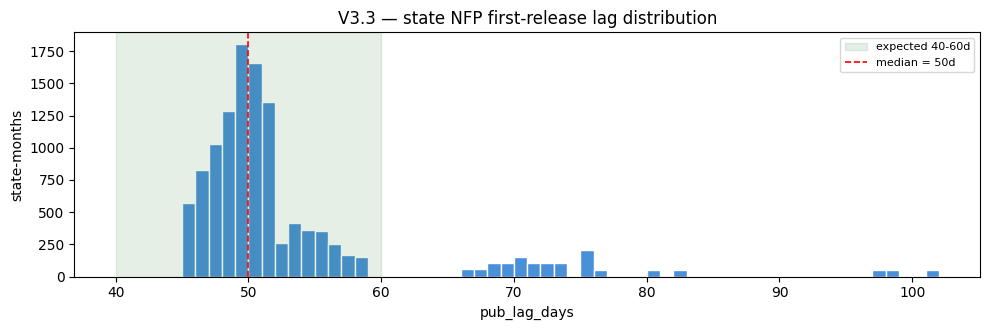

[PASS] V3.3   State publication lag ~50 days (joint state emp/unemp report)  |  median 50d (IQR 48-53)  (criterion: median in [40, 60] days)
       note: released together with state U3, ~3 weeks after national


In [21]:
# V3.3 — state publication lag
_lag = df_v["pub_lag_days"]; med = float(_lag.median())
print("V3.3 — state NFP publication lag (criterion: median in [40, 60] days):")
print(_lag.describe().round(1).to_frame("pub_lag_days").T.to_string())
print(f"  median={med:.0f}d  (~{med/30:.1f} months; released with state U3, ~3 weeks after the national report)")
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(_lag, bins=range(int(_lag.min()), int(_lag.max()) + 2), color="#4a90d9", edgecolor="white")
ax.axvspan(40, 60, color="#2e7d32", alpha=0.12, label="expected 40-60d")
ax.axvline(med, color="red", ls="--", lw=1.2, label=f"median = {med:.0f}d")
ax.set_xlabel("pub_lag_days"); ax.set_ylabel("state-months"); ax.set_title("V3.3 — state NFP first-release lag distribution")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
add_check("V3", "V3.3", "State publication lag ~50 days (joint state emp/unemp report)",
          "PASS" if 40 <= med <= 60 else "WARN",
          metric=f"median {med:.0f}d (IQR {_lag.quantile(.25):.0f}-{_lag.quantile(.75):.0f})",
          threshold="median in [40, 60] days", note="released together with state U3, ~3 weeks after national")

## V3.4 — Do state releases follow the national jobs report?

V3.4 — state release vs national jobs report (criterion: >= 95% after national):
  share released after national: 100.0%  median gap +14d
            count  mean  std   min   25%   50%   75%   max
gap_days  11796.0  17.7  7.3  14.0  14.0  14.0  18.0  56.0


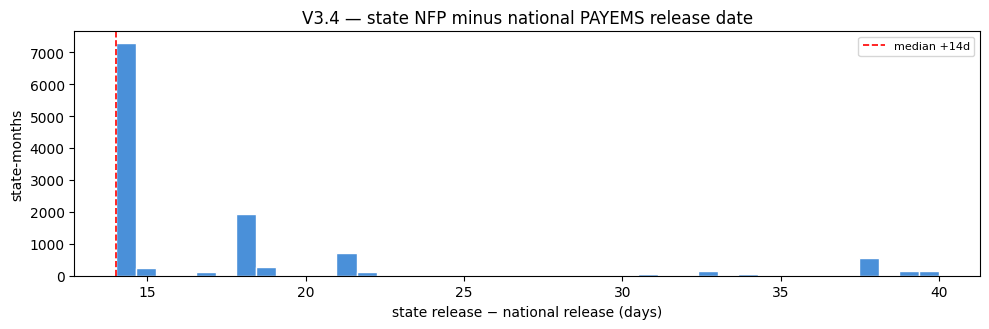

[PASS] V3.4   State NFP published after the national jobs report  |  100.0% after national; median gap +14d  (criterion: >= 95% after national)
       note: state detail follows the national aggregate


In [22]:
# V3.4 — state first release lands after the national PAYEMS release for the same month
nat_rel = nat_v.set_index("obs_date")["first_release_date"]
al = df_v[["state", "obs_date", "first_release_date", "pub_lag_days"]].copy()
al["nat_release"] = al["obs_date"].map(nat_rel)
al = al.dropna(subset=["nat_release"]); al["gap_days"] = (al["first_release_date"] - al["nat_release"]).dt.days
after = (al["gap_days"] > 0).mean()
print("V3.4 — state release vs national jobs report (criterion: >= 95% after national):")
print(f"  share released after national: {after:.1%}  median gap +{al['gap_days'].median():.0f}d")
print(al["gap_days"].describe().round(1).to_frame("gap_days").T.to_string())
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(al["gap_days"].clip(0, 40), bins=41, color="#4a90d9", edgecolor="white")
ax.axvline(al["gap_days"].median(), color="red", ls="--", lw=1.2, label=f"median +{al['gap_days'].median():.0f}d")
ax.set_xlabel("state release − national release (days)"); ax.set_ylabel("state-months")
ax.set_title("V3.4 — state NFP minus national PAYEMS release date"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
add_check("V3", "V3.4", "State NFP published after the national jobs report",
          "PASS" if after >= 0.95 else "WARN",
          metric=f"{after:.1%} after national; median gap +{al['gap_days'].median():.0f}d",
          threshold=">= 95% after national", note="state detail follows the national aggregate")

## V3.5 — Is the publication-lag regime stable over time?

V3.5 — publication-lag regime stability (criterion: yearly median range <= 7 days):
  median lag by year spans 48-66d (range 18d)
rel_year    2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
median_lag  49.5  50.5  50.0  48.5  50.0  50.5  49.5  50.0  49.5  49.5  50.5  49.5  49.5  49.5  49.0  49.5  50.0  49.0  49.5  49.5  52.0  66.5


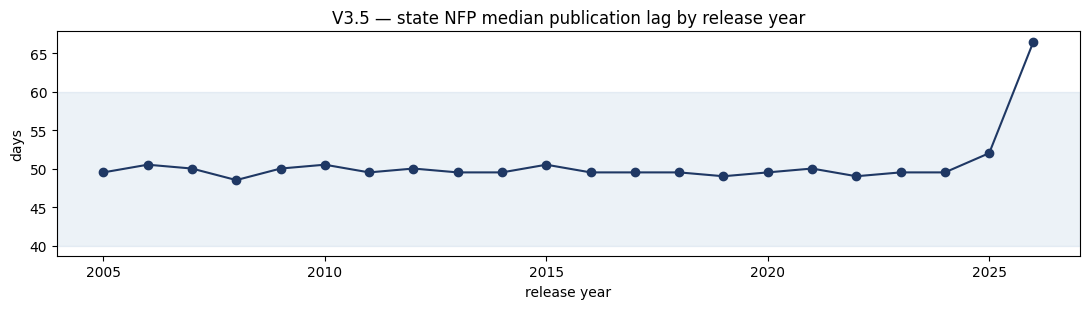

[WARN] V3.5   Publication-lag regime stable over time  |  yearly median range 18d (48-66d)  (criterion: yearly median range <= 7 days)
       note: a stable lag lets a backtest assume a single availability rule


In [23]:
# V3.5 — lag stability by release year
df_v["rel_year"] = df_v["first_release_date"].dt.year
lag_by_year = df_v.groupby("rel_year")["pub_lag_days"].median()
lag_range = lag_by_year.max() - lag_by_year.min()
print("V3.5 — publication-lag regime stability (criterion: yearly median range <= 7 days):")
print(f"  median lag by year spans {lag_by_year.min():.0f}-{lag_by_year.max():.0f}d (range {lag_range:.0f}d)")
print(lag_by_year.round(1).to_frame("median_lag").T.to_string())
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(lag_by_year.index, lag_by_year.values, marker="o", color="#1f3864")
ax.axhspan(40, 60, color="steelblue", alpha=0.10)
ax.set(title="V3.5 — state NFP median publication lag by release year", ylabel="days", xlabel="release year")
plt.tight_layout(); plt.show()
add_check("V3", "V3.5", "Publication-lag regime stable over time",
          "PASS" if lag_range <= 7 else "WARN",
          metric=f"yearly median range {lag_range:.0f}d ({lag_by_year.min():.0f}-{lag_by_year.max():.0f}d)",
          threshold="yearly median range <= 7 days", note="a stable lag lets a backtest assume a single availability rule")

## V3.6 — Do months become available in order (monotone frontier)?

V3.6 — availability-frontier monotonicity (criterion: 0 inversions):
  total inversions: 0
  (all states monotone)


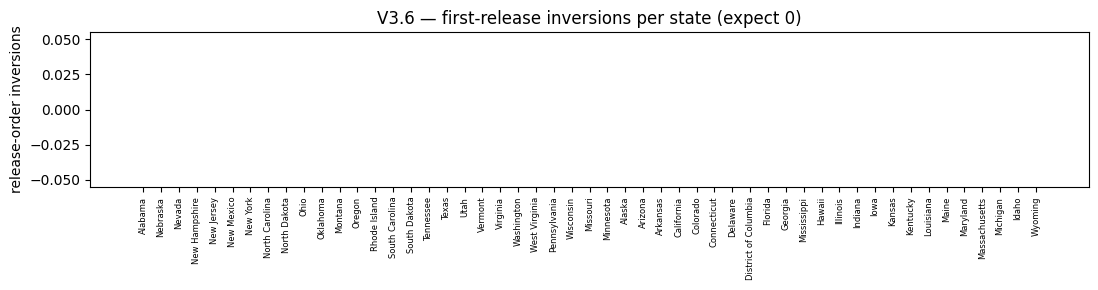

[PASS] V3.6   Release dates weakly increasing in obs order (per state)  |  0 inversions  (criterion: == 0)
       note: the PIT builder uses the cummax release frontier, so small inversions are harmless


In [24]:
# V3.6 — release dates weakly increasing in observation order, per state
per_state_inv = {}
inversions = 0
for state, g in df_v.groupby("state"):
    rel = g.sort_values("obs_date")["first_release_date"].values
    n = int((rel[1:] < rel[:-1]).sum()); per_state_inv[state] = n; inversions += n
print("V3.6 — availability-frontier monotonicity (criterion: 0 inversions):")
print(f"  total inversions: {inversions}")
_bad = {s: n for s, n in per_state_inv.items() if n}
print("  (all states monotone)" if not _bad else f"  states with inversions: {_bad}")
vals = pd.Series(per_state_inv).sort_values()
fig, ax = plt.subplots(figsize=(11, 3.0))
ax.bar(range(len(vals)), vals.values, color=["#2e7d32" if v == 0 else "#d94a4a" for v in vals.values], width=0.85)
ax.set_xticks(range(len(vals))); ax.set_xticklabels(vals.index, rotation=90, fontsize=6)
ax.set_ylabel("release-order inversions"); ax.set_title("V3.6 — first-release inversions per state (expect 0)")
plt.tight_layout(); plt.show()
add_check("V3", "V3.6", "Release dates weakly increasing in obs order (per state)",
          "PASS" if inversions == 0 else "WARN", metric=f"{inversions} inversions", threshold="== 0",
          note="the PIT builder uses the cummax release frontier, so small inversions are harmless")

## V3.7 — Does the PIT panel contain any look-ahead?

V3.7 — PIT look-ahead guard (criterion: 0 violations, 0 unmatched):
  violations (released AFTER as_of): 0
  unmatched latest-obs keys:         0
  data-staleness (nfp_lag_months): median=2  min=2  max=4


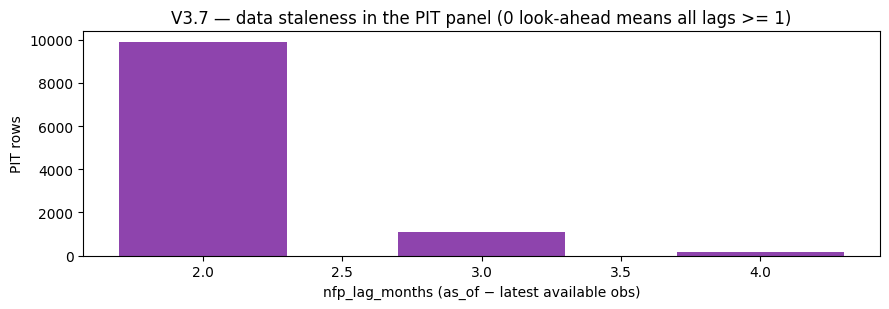

[PASS] V3.7   PIT panel look-ahead guard (nfp_latest_obs released <= as_of_date)  |  0 violations, 0 unmatched of 11,133 rows  (criterion: == 0)


In [25]:
# V3.7 — hard look-ahead guard
rel_lookup = df_v.set_index(["state", "obs_date"])["first_release_date"]
keys = pd.MultiIndex.from_arrays([pit["state"], pit["nfp_latest_obs"]])
pit_rel = rel_lookup.reindex(keys).values
violations = int((pd.to_datetime(pit_rel) > pit["as_of_date"]).sum())
unmatched = int(pd.isna(pit_rel).sum())
_lag_months = pit["nfp_lag_months"]
print("V3.7 — PIT look-ahead guard (criterion: 0 violations, 0 unmatched):")
print(f"  violations (released AFTER as_of): {violations}")
print(f"  unmatched latest-obs keys:         {unmatched}")
print(f"  data-staleness (nfp_lag_months): median={_lag_months.median():.0f}  min={_lag_months.min()}  max={_lag_months.max()}")
vc = _lag_months.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(vc.index, vc.values, color="#8e44ad", width=0.6)
ax.set_xlabel("nfp_lag_months (as_of − latest available obs)"); ax.set_ylabel("PIT rows")
ax.set_title("V3.7 — data staleness in the PIT panel (0 look-ahead means all lags >= 1)")
plt.tight_layout(); plt.show()
add_check("V3", "V3.7", "PIT panel look-ahead guard (nfp_latest_obs released <= as_of_date)",
          "PASS" if violations == 0 and unmatched == 0 else "FAIL",
          metric=f"{violations} violations, {unmatched} unmatched of {len(pit):,} rows", threshold="== 0")

## V4 — Revision behavior: first release and after

The central module for NFP: CES is revised almost every month, then benchmarked annually to QCEW. Revisions are measured in **percent of the first print** (the level is a count, so % change is the natural unit).

| Check | Question it answers |
|---|---|
| V4.1 | How often, and by how much, does a first print get revised (endpoint: first vs current)? |
| V4.2 | Do revisions cluster at the annual (winter) QCEW benchmark? |
| V4.3 | Is there a systematic bias in first prints? |
| V4.4 | How large is the national PAYEMS revision (calibration)? |

## V4.1 — How often does a first print get revised (endpoint: first vs current)?

V4.1 — endpoint revision rate & magnitude (criterion: informational; NFP heavily revised):
  rows compared: 11,796
  revised (|rev| > 0):  99%
  median |rev|:  0.55%   p90 1.63%   max 7.5%


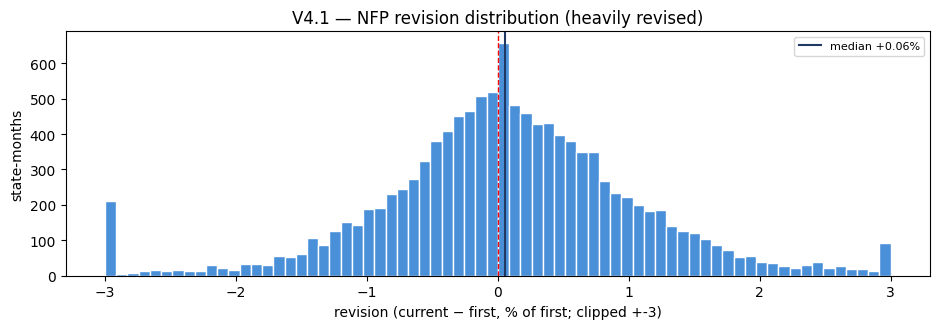


V4.1 — largest upward revisions (%):
     state obs_date first_release_date  value_first_release  value_current  revision  revision_pct
    Nevada  2021-12         2022-01-25               1372.2         1442.8      70.6      5.145023
    Nevada  2021-11         2021-12-17               1367.5         1434.0      66.5      4.862888
    Hawaii  2021-11         2021-12-17                577.5          603.6      26.1      4.519481
    Hawaii  2021-12         2022-01-25                580.1          606.1      26.0      4.481986
    Hawaii  2021-10         2021-11-19                576.9          602.4      25.5      4.420177
    Nevada  2021-10         2021-11-19               1363.8         1423.5      59.7      4.377475
Washington  2020-04         2020-05-22               2968.4         3096.9     128.5      4.328931
    Hawaii  2021-08         2021-09-17                576.4          600.5      24.1      4.181124
    Nevada  2021-07         2021-08-20               1335.9         139

In [26]:
# V4.1 — endpoint revision: first release vs current (percent of first print)
rev = df_v.merge(sa_c[["state", "obs_date", "value_current"]], on=["state", "obs_date"], how="inner")
rev["revision"] = rev["value_current"] - rev["value_first_release"]
rev["revision_pct"] = rev["revision"] / rev["value_first_release"] * 100
share_rev = (rev["revision"].abs() > 1e-9).mean()
print("V4.1 — endpoint revision rate & magnitude (criterion: informational; NFP heavily revised):")
print(f"  rows compared: {len(rev):,}")
print(f"  revised (|rev| > 0):  {share_rev:.0%}")
print(f"  median |rev|:  {rev['revision_pct'].abs().median():.2f}%   p90 {rev['revision_pct'].abs().quantile(.9):.2f}%   max {rev['revision_pct'].abs().max():.1f}%")
fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.hist(rev["revision_pct"].clip(-3, 3), bins=70, color="#4a90d9", edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1)
ax.axvline(rev["revision_pct"].median(), color="#1f3864", lw=1.5, label=f"median {rev['revision_pct'].median():+.2f}%")
ax.set_xlabel("revision (current − first, % of first; clipped +-3)"); ax.set_ylabel("state-months")
ax.set_title("V4.1 — NFP revision distribution (heavily revised)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("\nV4.1 — largest upward revisions (%):")
cols = ["state", "obs_date", "first_release_date", "value_first_release", "value_current", "revision", "revision_pct"]
_top = rev.nlargest(10, "revision_pct")[cols].copy()
_top["obs_date"] = _top["obs_date"].dt.strftime("%Y-%m"); _top["first_release_date"] = _top["first_release_date"].dt.strftime("%Y-%m-%d")
print(_top.to_string(index=False))
rev.to_csv("nfp_revisions.csv", index=False)
add_check("V4", "V4.1", "Endpoint revision rate & magnitude (first release vs current)",
          "WARN" if share_rev > 0.05 else "PASS",
          metric=f"{share_rev:.0%} revised; median |rev| {rev['revision_pct'].abs().median():.2f}%, max {rev['revision_pct'].abs().max():.1f}%",
          threshold="informational — NFP is heavily revised by design",
          note="the opposite of claims: current values embed benchmark corrections unknown in real time; backtests MUST use vintage data")

## V4.2 — Do revisions cluster at the annual (winter) QCEW benchmark?

V4.2 — release month of each obs-month's LARGEST revision (criterion: >= 60% in Jan-Apr):
  Jan-Apr share: 99%   modal month: 3  (1249 of 1308 obs, CA/TX/NY)


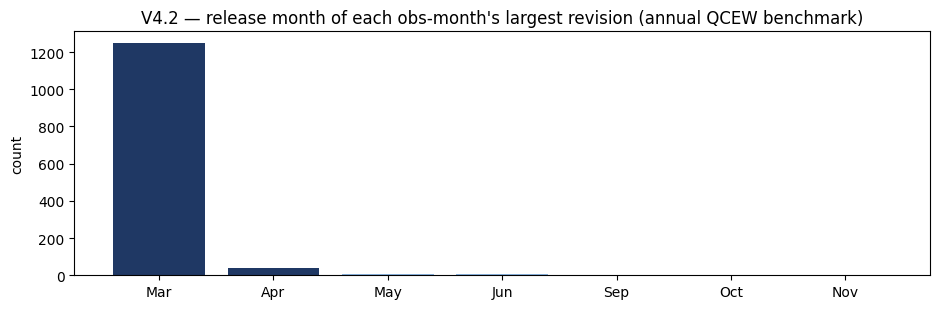

[PASS] V4.2   Revisions cluster at the annual benchmark (Feb/Mar release months)  |  99% of largest revisions in Jan-Apr; modal month = 3  (criterion: >= 60% in the winter benchmark window)
       note: the annual QCEW re-anchoring drives the big revisions; apply on release date, not backward


In [27]:
# V4.2 — full vintage trajectories (output_type=2) for sample states: when do biggest revisions land?
BENCH = {"CANA": "California", "TXNA": "Texas", "NYNA": "New York"}
bench_months = []
for sid, name in BENCH.items():
    d = fred_get({"series_id": sid, "realtime_start": "1776-07-04", "realtime_end": "9999-12-31",
                  "output_type": 2, "limit": 100000})
    t = pd.DataFrame(d["observations"]).set_index("date")
    vcols = [c for c in t.columns if c.startswith(sid)]
    vals = t[vcols].replace(".", np.nan).astype(float)
    vals.columns = pd.to_datetime([c.split("_", 1)[1] for c in vcols])
    for obs in vals.index:
        row = vals.loc[obs].dropna()
        if len(row) < 2:
            continue
        steps = row.diff().abs()
        if steps.max() > 0:
            bench_months.append(steps.idxmax().month)
    time.sleep(0.3)
bm = pd.Series(bench_months).value_counts().sort_index()
winter = bm.reindex([1, 2, 3, 4]).sum() / bm.sum()
print("V4.2 — release month of each obs-month's LARGEST revision (criterion: >= 60% in Jan-Apr):")
print(f"  Jan-Apr share: {winter:.0%}   modal month: {bm.idxmax()}  ({bm.max()} of {bm.sum()} obs, CA/TX/NY)")
_mn = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.bar([_mn[m-1] for m in bm.index], bm.values, color=["#1f3864" if m in (1,2,3,4) else "#8ab4e0" for m in bm.index])
ax.set(title="V4.2 — release month of each obs-month's largest revision (annual QCEW benchmark)", ylabel="count")
plt.tight_layout(); plt.show()
add_check("V4", "V4.2", "Revisions cluster at the annual benchmark (Feb/Mar release months)",
          "PASS" if winter >= 0.6 else "WARN",
          metric=f"{winter:.0%} of largest revisions in Jan-Apr; modal month = {bm.idxmax()}",
          threshold=">= 60% in the winter benchmark window",
          note="the annual QCEW re-anchoring drives the big revisions; apply on release date, not backward")

## V4.3 — Is there a systematic bias in first prints?

V4.3 — systematic bias in first prints (criterion: |mean revision| < 0.10%):
  mean revision: +0.052%  (first prints understate on average)
  median: +0.057%   std: 1.11%


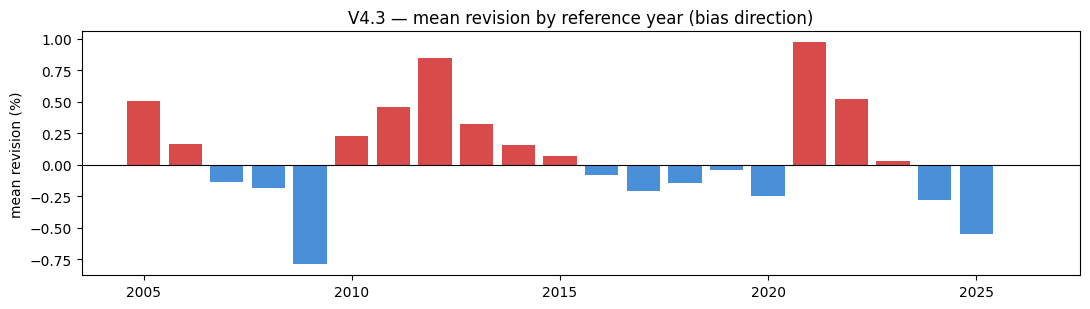

[PASS] V4.3   Systematic bias in first prints  |  mean revision +0.052%  (criterion: |mean| < 0.10%)
       note: a persistent sign means first prints are predictably off — a modellable nowcast signal


In [28]:
# V4.3 — directional bias of first prints
bias = rev["revision_pct"].mean()
print("V4.3 — systematic bias in first prints (criterion: |mean revision| < 0.10%):")
print(f"  mean revision: {bias:+.3f}%  (first prints {'understate' if bias > 0 else 'overstate'} on average)")
print(f"  median: {rev['revision_pct'].median():+.3f}%   std: {rev['revision_pct'].std():.2f}%")
_by_year = rev.assign(y=rev["obs_date"].dt.year).groupby("y")["revision_pct"].mean()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(_by_year.index, _by_year.values, color=["#d94a4a" if v > 0 else "#4a90d9" for v in _by_year.values])
ax.axhline(0, color="black", lw=0.8)
ax.set(title="V4.3 — mean revision by reference year (bias direction)", ylabel="mean revision (%)")
plt.tight_layout(); plt.show()
add_check("V4", "V4.3", "Systematic bias in first prints",
          "PASS" if abs(bias) < 0.10 else "WARN",
          metric=f"mean revision {bias:+.3f}%", threshold="|mean| < 0.10%",
          note="a persistent sign means first prints are predictably off — a modellable nowcast signal")

## V4.4 — How large is the national PAYEMS revision (calibration)?

V4.4 — national PAYEMS revision (criterion: informational calibration):
  median +0.13%  IQR [-0.19, +0.46]  max |1.4|%


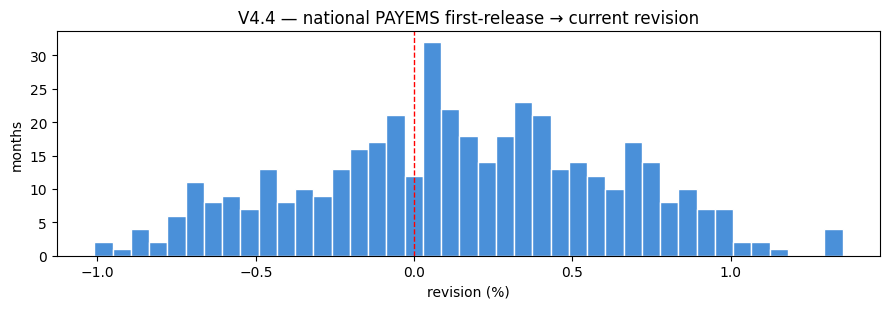

[PASS] V4.4   National PAYEMS revision benchmark quantified  |  median +0.13%, max |1.4|%  (criterion: informational calibration)
       note: the national series is revised on the same schedule; anchors state expectations


In [29]:
# V4.4 — national PAYEMS revision benchmark (first release vs current)
nat_rev = nat_v.merge(nat_cur[["obs_date", "value"]].rename(columns={"value": "current"}), on="obs_date", how="inner")
nat_rev["rev_pct"] = (nat_rev["current"] - nat_rev["value"]) / nat_rev["value"] * 100
print("V4.4 — national PAYEMS revision (criterion: informational calibration):")
print(f"  median {nat_rev['rev_pct'].median():+.2f}%  IQR [{nat_rev['rev_pct'].quantile(.25):+.2f}, {nat_rev['rev_pct'].quantile(.75):+.2f}]  max |{nat_rev['rev_pct'].abs().max():.1f}|%")
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(nat_rev["rev_pct"].clip(-1.5, 1.5), bins=41, color="#4a90d9", edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1)
ax.set(title="V4.4 — national PAYEMS first-release → current revision", xlabel="revision (%)", ylabel="months")
plt.tight_layout(); plt.show()
add_check("V4", "V4.4", "National PAYEMS revision benchmark quantified", "PASS",
          metric=f"median {nat_rev['rev_pct'].median():+.2f}%, max |{nat_rev['rev_pct'].abs().max():.1f}|%",
          threshold="informational calibration", note="the national series is revised on the same schedule; anchors state expectations")